# Healthcare Prescription Analysis
## Unsupervised Learning : Association Rule Based Learning
    The Model identifies the most frequent patterns and establishes a rule based on them.

## Importing Libraries

In [2]:
# Importing Pandas for data analysis and manipulation
import pandas as pd

# Importing NumPy for numerical operations
import numpy as np

# Importing Matplotlib for data visualization
import matplotlib.pyplot as plt

# Importing Seaborn for statistical data visualization
import seaborn as sns

In [3]:
df=pd.read_csv("/Users/suchismitarout/Downloads/healthcare_prescription_analytics_dataset.csv")

## Data Inspection

In [11]:
df.columns

Index(['Prescription_ID', 'Patient_ID', 'Patient_Age', 'Age_Group', 'Gender',
       'City', 'Department', 'Diagnosis', 'Medicine_Name', 'Medicine_Category',
       'Dosage', 'Quantity', 'Unit_Price', 'Total_Medicine_Cost',
       'Prescription_Date', 'Month', 'Season', 'Doctor_ID'],
      dtype='object')

In [12]:
df.shape

(36035, 18)

In [13]:
df.columns

Index(['Prescription_ID', 'Patient_ID', 'Patient_Age', 'Age_Group', 'Gender',
       'City', 'Department', 'Diagnosis', 'Medicine_Name', 'Medicine_Category',
       'Dosage', 'Quantity', 'Unit_Price', 'Total_Medicine_Cost',
       'Prescription_Date', 'Month', 'Season', 'Doctor_ID'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36035 entries, 0 to 36034
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Prescription_ID      36035 non-null  object 
 1   Patient_ID           36035 non-null  object 
 2   Patient_Age          36035 non-null  int64  
 3   Age_Group            36035 non-null  object 
 4   Gender               36035 non-null  object 
 5   City                 36035 non-null  object 
 6   Department           36035 non-null  object 
 7   Diagnosis            35689 non-null  object 
 8   Medicine_Name        36035 non-null  object 
 9   Medicine_Category    36035 non-null  object 
 10  Dosage               36035 non-null  object 
 11  Quantity             36035 non-null  int64  
 12  Unit_Price           36035 non-null  float64
 13  Total_Medicine_Cost  36035 non-null  float64
 14  Prescription_Date    36035 non-null  object 
 15  Month                36035 non-null 

In [15]:
df.isnull().sum()

Prescription_ID          0
Patient_ID               0
Patient_Age              0
Age_Group                0
Gender                   0
City                     0
Department               0
Diagnosis              346
Medicine_Name            0
Medicine_Category        0
Dosage                   0
Quantity                 0
Unit_Price               0
Total_Medicine_Cost      0
Prescription_Date        0
Month                    0
Season                   0
Doctor_ID                0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe()

,Patient_Age,Quantity,Unit_Price,Total_Medicine_Cost
count,36035.000000,36035.000000,36035.000000,36035.000000
mean,37.882226,7.923269,233.616176,1848.247543
std,21.300251,4.316388,124.320632,1505.398833
min,1.000000,1.000000,20.000000,20.120000
25%,22.000000,4.000000,126.270000,637.425000
50%,38.000000,8.000000,232.770000,1399.100000
75%,53.000000,12.000000,341.510000,2733.360000
max,92.000000,15.000000,450.000000,6746.850000


In [18]:
df.nunique()

Prescription_ID        12000
Patient_ID              4848
Patient_Age               92
Age_Group                  6
Gender                     3
City                      10
Department                 9
Diagnosis                 38
Medicine_Name            115
Medicine_Category         33
Dosage                    14
Quantity                  15
Unit_Price             24460
Total_Medicine_Cost    32992
Prescription_Date        485
Month                     12
Season                     3
Doctor_ID                150
dtype: int64

In [19]:
df.empty

False

# Visualisation

## 1. Univariate Analysis
### 1.1 Categorical Data Visualization

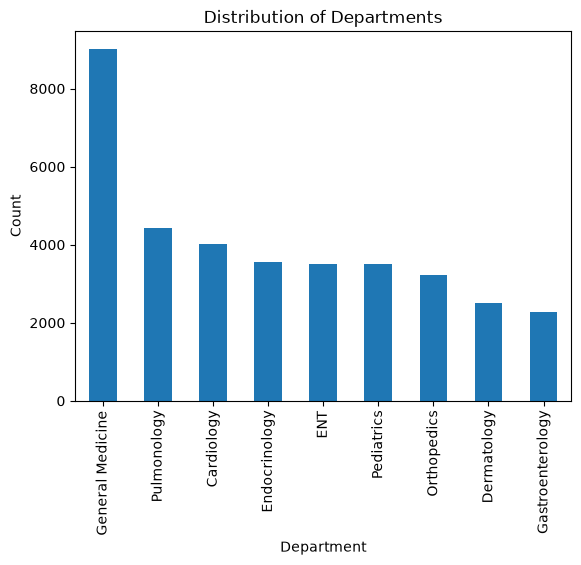

In [20]:
# Department distribution

df["Department"].value_counts().plot(kind="bar")

plt.xlabel("Department")
plt.ylabel("Count")
plt.title("Distribution of Departments")
plt.show()

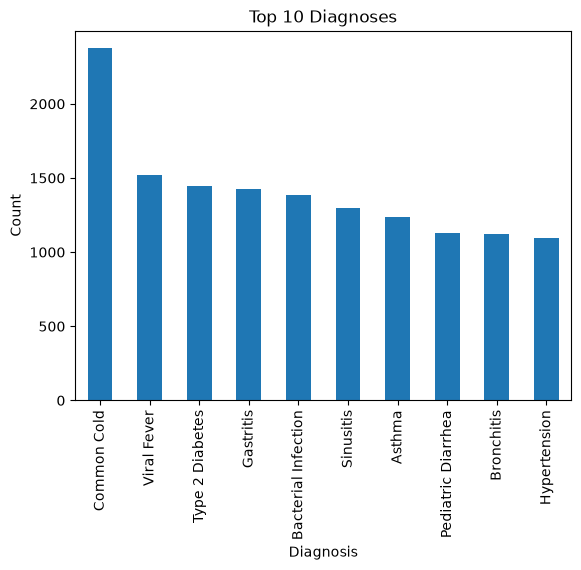

In [21]:
# Diagnosis distribution

df["Diagnosis"].value_counts().head(10).plot(kind="bar")

plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.title("Top 10 Diagnoses")
plt.xticks(rotation=90)
plt.show()

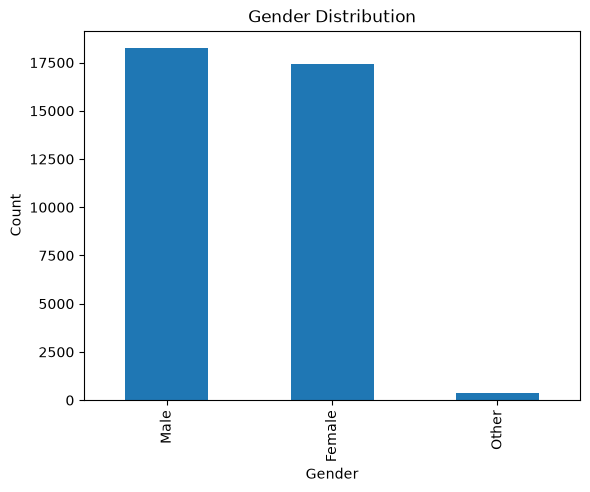

In [22]:
# Gender distribution

df["Gender"].value_counts().plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution")
plt.show()

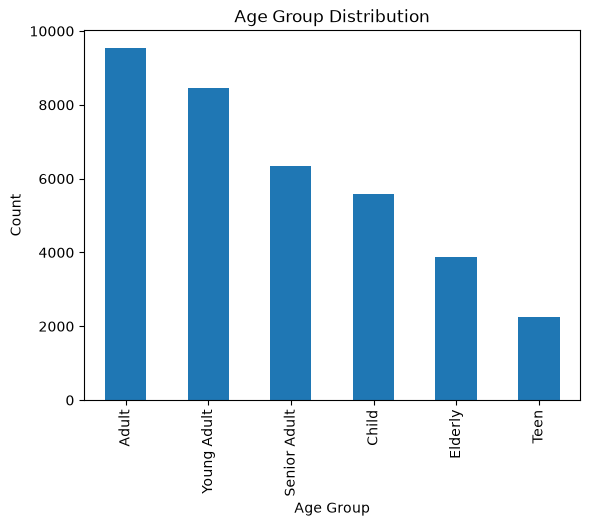

In [23]:
# Age group distribution

df["Age_Group"].value_counts().plot(kind="bar")

plt.xlabel("Age Group")
plt.ylabel("Count")
plt.title("Age Group Distribution")
plt.show()

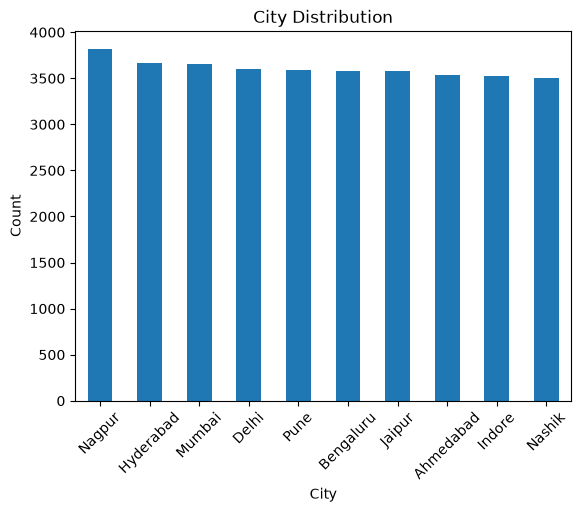

In [24]:
# City distribution

df["City"].value_counts().plot(kind="bar")

plt.xlabel("City")
plt.ylabel("Count")
plt.title("City Distribution")
plt.xticks(rotation=45)
plt.show()

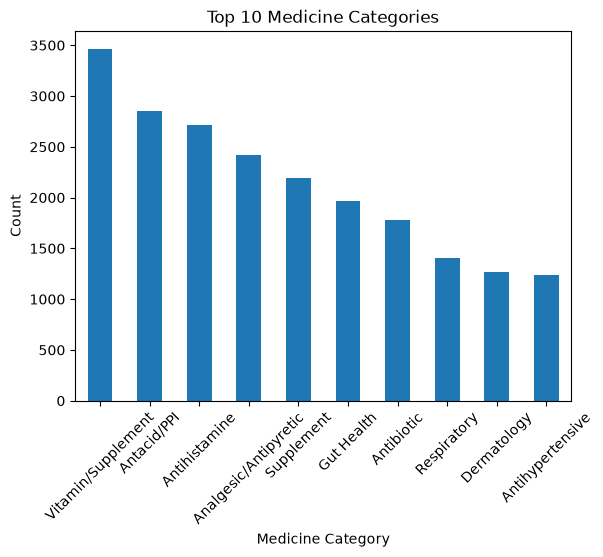

In [25]:
# Medicine category distribution

df["Medicine_Category"].value_counts().head(10).plot(kind="bar")

plt.xlabel("Medicine Category")
plt.ylabel("Count")
plt.title("Top 10 Medicine Categories")
plt.xticks(rotation=45)
plt.show()


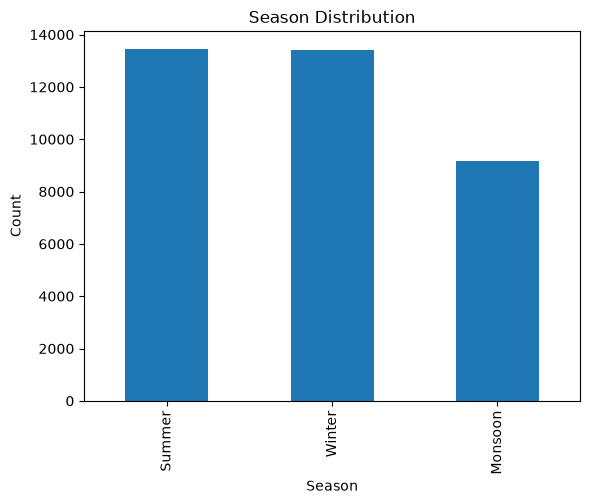

In [26]:
# Season distribution

df["Season"].value_counts().plot(kind="bar")

plt.xlabel("Season")
plt.ylabel("Count")
plt.title("Season Distribution")
plt.show()

### Observation – Categorical Data

The categorical data shows that General Medicine has the highest share of prescriptions, around *23.7%*, followed by Pediatrics at about *11.8%*. Other departments have relatively smaller shares. Overall, the prescription records are mainly concentrated in a few departments, while the remaining departments have a more balanced distribution.

## 1.2 Numerical Data Visualization

In [27]:
# Numerical columns

df.select_dtypes(include="number").columns

Index(['Patient_Age', 'Quantity', 'Unit_Price', 'Total_Medicine_Cost'], dtype='object')

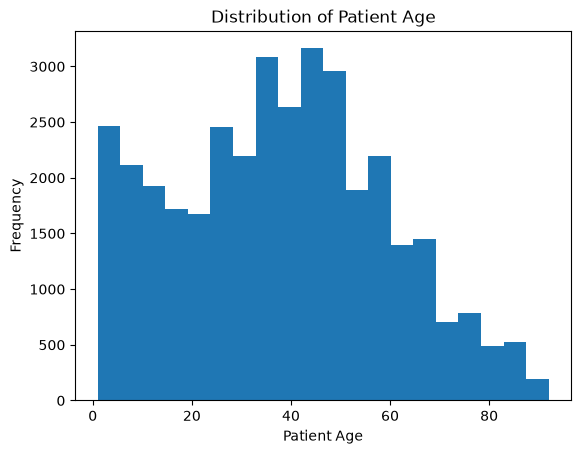

In [28]:
# Distribution of patient age

df["Patient_Age"].plot(kind="hist", bins=20)

plt.xlabel("Patient Age")
plt.ylabel("Frequency")
plt.title("Distribution of Patient Age")
plt.show()

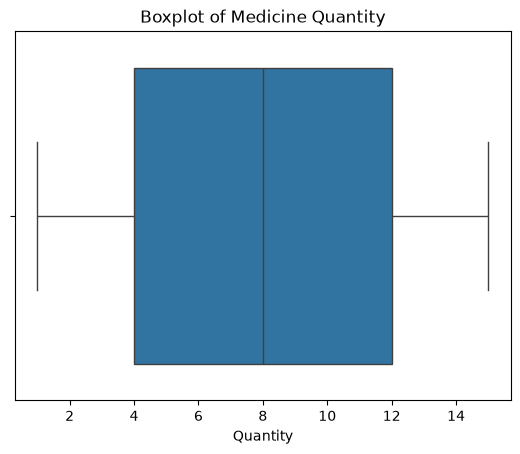

In [4]:
# Boxplot of medicine quantity

sns.boxplot(x=df["Quantity"])

plt.title("Boxplot of Medicine Quantity")
plt.show()

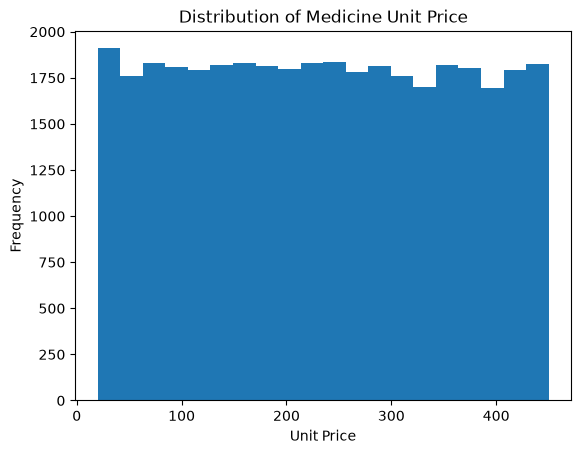

In [30]:
# Distribution of medicine unit price

df["Unit_Price"].plot(kind="hist", bins=20)

plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.title("Distribution of Medicine Unit Price")
plt.show()

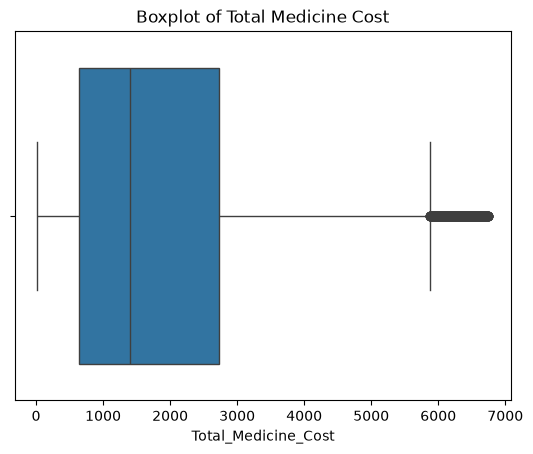

In [5]:
# Boxplot of total medicine cost

sns.boxplot(x=df["Total_Medicine_Cost"])

plt.title("Boxplot of Total Medicine Cost")
plt.show()

### Observation – Numerical Data

The numerical variables show that patient age and medicine quantity are mostly concentrated around their average values, while unit price and total medicine cost show more variation. The boxplots also show some higher-value outliers, especially in medicine cost, indicating that a few records have unusually expensive medicines.

# 2. Bivariate Analysis

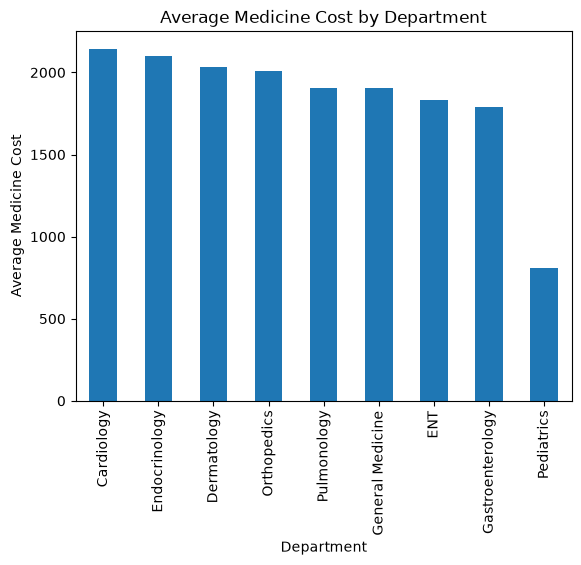

In [32]:
# Department vs Prescription Cost
# Average medicine cost by department

df.groupby("Department")["Total_Medicine_Cost"].mean().sort_values(ascending=False).plot(
    kind="bar"
)

plt.xlabel("Department")
plt.ylabel("Average Medicine Cost")
plt.title("Average Medicine Cost by Department")
plt.show()

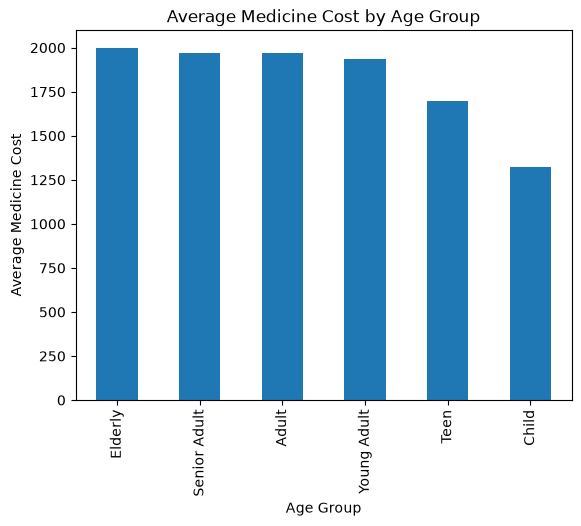

In [33]:
# Age Group vs Medicine Cost
# Average medicine cost by age group

df.groupby("Age_Group")["Total_Medicine_Cost"].mean().sort_values(ascending=False).plot(
    kind="bar"
)

plt.xlabel("Age Group")
plt.ylabel("Average Medicine Cost")
plt.title("Average Medicine Cost by Age Group")
plt.show()

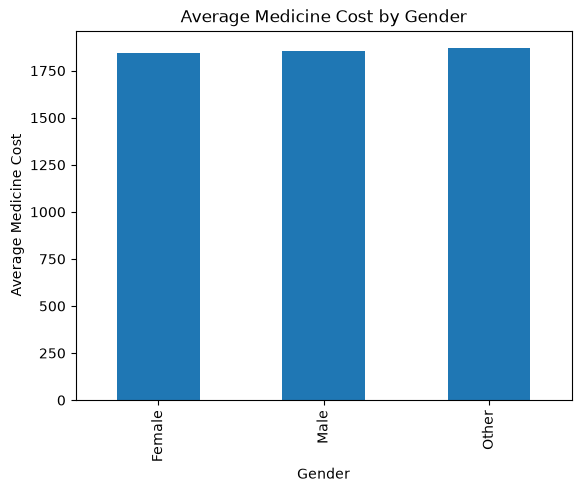

In [34]:
# Gender vs Medicine Cost
# Average medicine cost by gender

df.groupby("Gender")["Total_Medicine_Cost"].mean().plot(
    kind="bar"
)

plt.xlabel("Gender")
plt.ylabel("Average Medicine Cost")
plt.title("Average Medicine Cost by Gender")
plt.show()

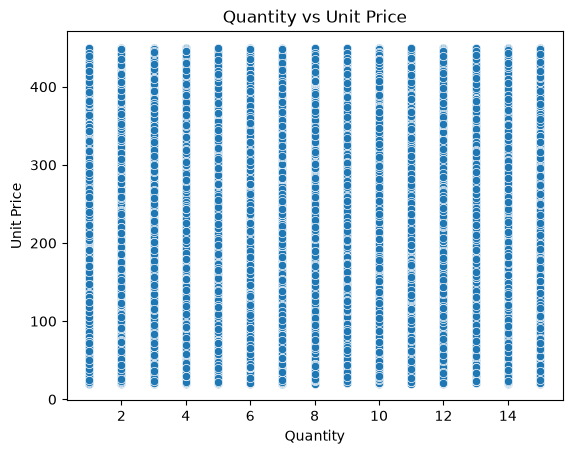

In [35]:
# Quantity vs Unit Price
# Relationship between quantity and unit price

sns.scatterplot(
    x=df["Quantity"],
    y=df["Unit_Price"]
)

plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.title("Quantity vs Unit Price")
plt.show()

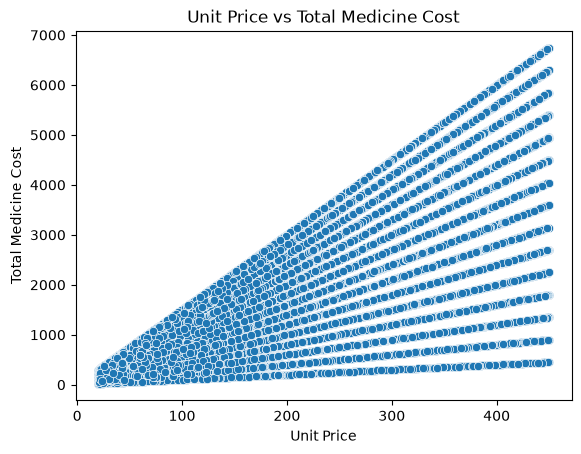

In [36]:
# Unit Price vs Total Medicine Cost
# Relationship between unit price and total medicine cost

sns.scatterplot(x=df["Unit_Price"],y=df["Total_Medicine_Cost"])

plt.xlabel("Unit Price")
plt.ylabel("Total Medicine Cost")
plt.title("Unit Price vs Total Medicine Cost")
plt.show()

### Observation – Bivariate Analysis

The bivariate analysis shows that medicine cost varies across different departments and age groups. Some departments have higher average costs than others, while the relationship between unit price and total medicine cost shows that higher-priced medicines generally contribute to higher total costs.

# 3. Multivariate Analysis

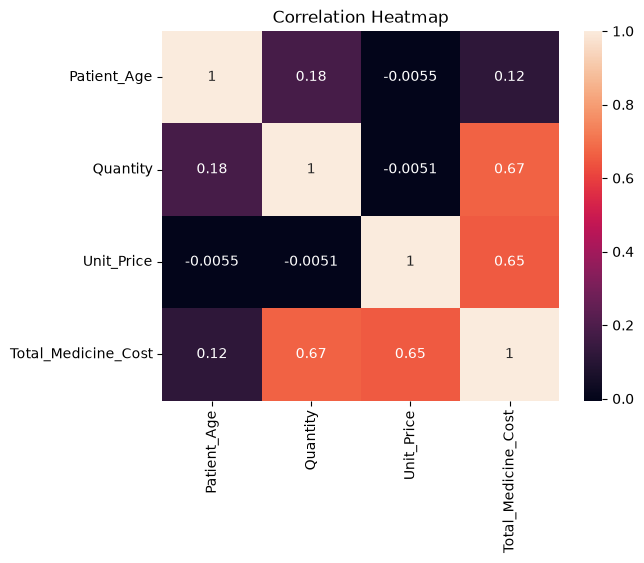

In [37]:
#1 Correlation Heatmap
# Correlation between numerical variables
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

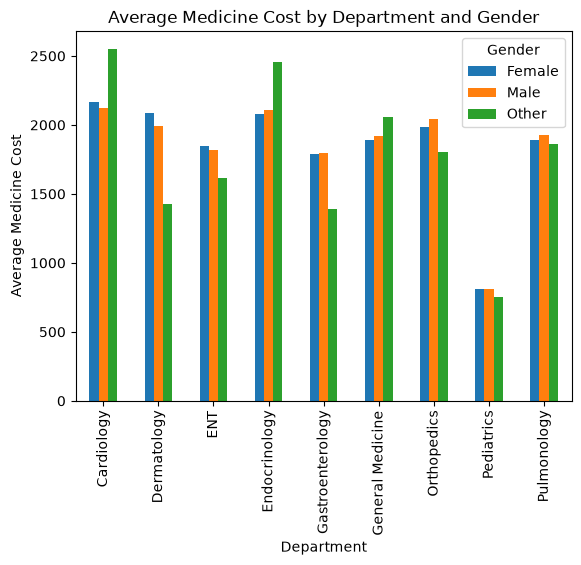

In [38]:
#2 Department, Gender and Medicine Cost
# Average medicine cost by department and gender
df.groupby(["Department","Gender"])["Total_Medicine_Cost"].mean().unstack().plot(kind="bar")
plt.title("Average Medicine Cost by Department and Gender")
plt.ylabel("Average Medicine Cost")
plt.show()

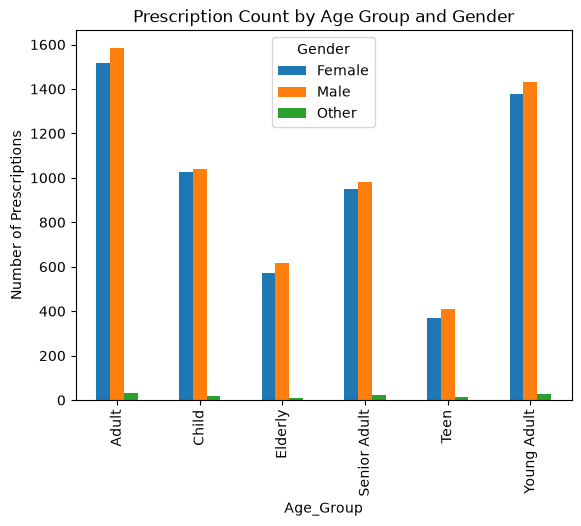

In [39]:
#3. Age Group, Gender and Prescription Count
# Prescription count by age group and gender
df.groupby(["Age_Group","Gender"])["Prescription_ID"].nunique().unstack().plot(kind="bar")
plt.title("Prescription Count by Age Group and Gender")
plt.ylabel("Number of Prescriptions")
plt.show()

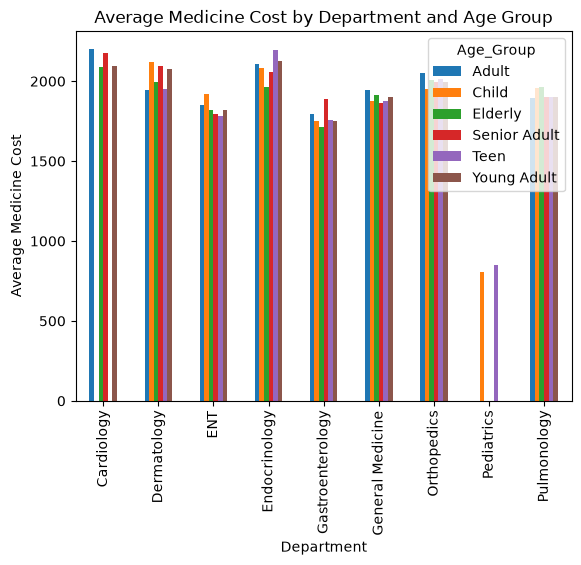

In [40]:
#4. Department, Age Group and Medicine Cost
# Average medicine cost by department and age group
df.groupby(["Department","Age_Group"])["Total_Medicine_Cost"].mean().unstack().plot(kind="bar")
plt.title("Average Medicine Cost by Department and Age Group")
plt.ylabel("Average Medicine Cost")
plt.show()

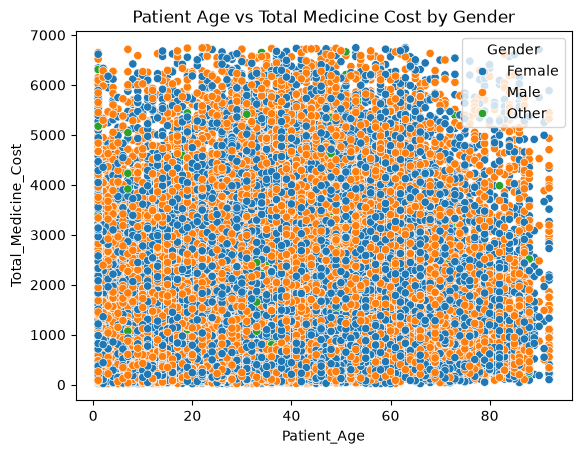

In [41]:
#5. Relationship between patient age, total medicine cost and gender
sns.scatterplot(data=df, x="Patient_Age", y="Total_Medicine_Cost", hue="Gender")
plt.title("Patient Age vs Total Medicine Cost by Gender")
plt.show()

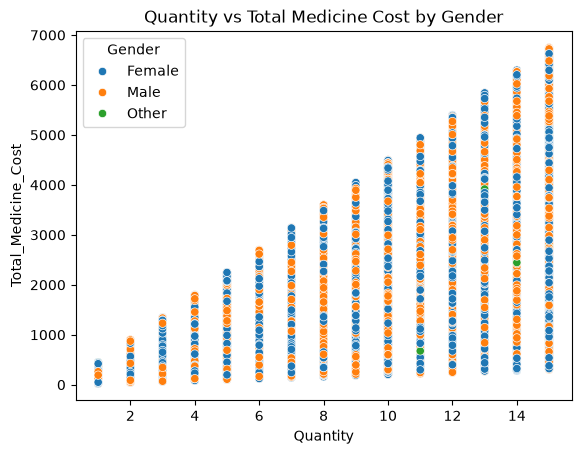

In [42]:
#6. Relationship between quantity, total medicine cost and gender
sns.scatterplot(data=df, x="Quantity", y="Total_Medicine_Cost", hue="Gender")
plt.title("Quantity vs Total Medicine Cost by Gender")
plt.show()

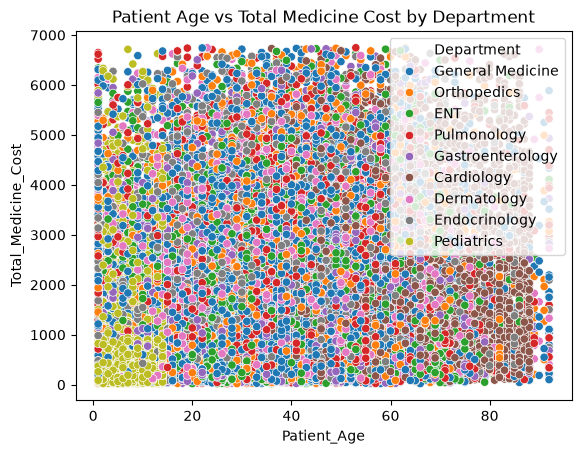

In [43]:
#7. Relationship between patient age, total medicine cost and department
sns.scatterplot(data=df, x="Patient_Age", y="Total_Medicine_Cost", hue="Department")
plt.title("Patient Age vs Total Medicine Cost by Department")
plt.show()

### Observation – Multivariate Analysis

The multivariate analysis shows that total medicine cost generally increases with unit price and quantity. The patterns also vary across different genders, departments, and medicine categories. Some points are far from the main group, which may indicate high-cost or unusual prescriptions.

In [44]:
# 1. Which diagnoses account for the highest number of unique prescriptions, and how large is the gap between the leading diagnoses and the rest?

diagnosis_counts = df.groupby("Diagnosis")["Prescription_ID"].nunique().sort_values(ascending=False)

print("Top 5 diagnoses by number of prescriptions:")
print(diagnosis_counts.head(5))

gap = diagnosis_counts.iloc[0] - diagnosis_counts.iloc[1]

print("\nTop diagnosis:", diagnosis_counts.index[0])
print("Number of prescriptions:", diagnosis_counts.iloc[0])
print("Gap between the top diagnosis and the second-highest:", gap)

Top 5 diagnoses by number of prescriptions:
Diagnosis
Common Cold            654
Gastritis              532
Pediatric Diarrhea     438
Viral Fever            418
Diabetic Neuropathy    407
Name: Prescription_ID, dtype: int64

Top diagnosis: Common Cold
Number of prescriptions: 654
Gap between the top diagnosis and the second-highest: 122


In [45]:
# 2. Which departments handle the highest prescription volume, and what patterns distinguish high-volume departments from low-volume departments?

department_volume = df.groupby("Department").agg(
    Prescriptions=("Prescription_ID", "nunique"),
    Patients=("Patient_ID", "nunique")
).sort_values("Prescriptions", ascending=False)

print("Prescription volume by department:")
print(department_volume)

print("\nHighest-volume department:", department_volume.index[0])
print("Number of prescriptions:", department_volume.iloc[0]["Prescriptions"])

print("\nLowest-volume department:", department_volume.index[-1])
print("Number of prescriptions:", department_volume.iloc[-1]["Prescriptions"])

Prescription volume by department:
                  Prescriptions  Patients
Department                               
General Medicine           2843      2216
Pediatrics                 1412      1244
Cardiology                 1238      1106
Pulmonology                1210      1100
Endocrinology              1201      1102
ENT                        1191      1065
Orthopedics                1110      1014
Dermatology                 941       871
Gastroenterology            854       787

Highest-volume department: General Medicine
Number of prescriptions: 2843

Lowest-volume department: Gastroenterology
Number of prescriptions: 854


In [46]:
# 3. Which departments generate the highest total medicine expenditure, and does this ranking match their prescription volume?

department_cost = df.groupby("Department").agg(
    Total_Expenditure=("Total_Medicine_Cost", "sum"),
    Prescriptions=("Prescription_ID", "nunique")
).sort_values("Total_Expenditure", ascending=False)

print("Department-wise medicine expenditure and prescription volume:")
print(department_cost)

Department-wise medicine expenditure and prescription volume:
                  Total_Expenditure  Prescriptions
Department                                        
General Medicine        17179178.03           2843
Cardiology               8608065.55           1238
Pulmonology              8465203.35           1210
Endocrinology            7450427.29           1201
Orthopedics              6460344.85           1110
ENT                      6424575.27           1191
Dermatology              5085307.56            941
Gastroenterology         4092026.98            854
Pediatrics               2836471.32           1412


In [47]:
# 4. Which departments have the highest average cost per prescription, and what may be driving these differences?

department_cost = df.groupby("Department").agg(
    Total_Cost=("Total_Medicine_Cost", "sum"),
    Prescriptions=("Prescription_ID", "nunique")
).assign(
    Average_Cost=lambda x: x["Total_Cost"] / x["Prescriptions"]
).sort_values("Average_Cost", ascending=False)

print("Average prescription cost by department:")
print(department_cost)

Average prescription cost by department:
                   Total_Cost  Prescriptions  Average_Cost
Department                                                
Pulmonology        8465203.35           1210   6996.035826
Cardiology         8608065.55           1238   6953.203191
Endocrinology      7450427.29           1201   6203.519808
General Medicine  17179178.03           2843   6042.623296
Orthopedics        6460344.85           1110   5820.130495
Dermatology        5085307.56            941   5404.152561
ENT                6424575.27           1191   5394.269748
Gastroenterology   4092026.98            854   4791.600679
Pediatrics         2836471.32           1412   2008.832380


In [48]:
# 5. How does the average number of medicines included in a prescription vary across departments?

medicine_per_prescription = df.groupby(["Department", "Prescription_ID"])["Medicine_Name"].nunique().groupby("Department").mean().sort_values(ascending=False)

print("Average number of medicines per prescription by department:")
print(medicine_per_prescription)

print("\nDepartment with the highest average:", medicine_per_prescription.index[0])
print("Average medicines per prescription:", round(medicine_per_prescription.iloc[0], 2))

print("\nDepartment with the lowest average:", medicine_per_prescription.index[-1])
print("Average medicines per prescription:", round(medicine_per_prescription.iloc[-1], 2))

Average number of medicines per prescription by department:
Department
Pulmonology         3.666116
Cardiology          3.243134
General Medicine    3.172353
Endocrinology       2.955870
ENT                 2.945424
Orthopedics         2.894595
Gastroenterology    2.679157
Dermatology         2.658874
Pediatrics          2.481586
Name: Medicine_Name, dtype: float64

Department with the highest average: Pulmonology
Average medicines per prescription: 3.67

Department with the lowest average: Pediatrics
Average medicines per prescription: 2.48


In [49]:
# 6. Which departments prescribe the widest variety of medicine categories?

category_variety = df.groupby("Department")["Medicine_Category"].nunique().sort_values(ascending=False)

print("Number of different medicine categories prescribed by department:")
print(category_variety)

print("\nDepartment with the widest variety:", category_variety.index[0])
print("Number of medicine categories:", category_variety.iloc[0])

Number of different medicine categories prescribed by department:
Department
General Medicine    33
Cardiology          32
Endocrinology       32
Pediatrics          32
Orthopedics         31
Dermatology         30
ENT                 30
Gastroenterology    30
Pulmonology         30
Name: Medicine_Category, dtype: int64

Department with the widest variety: General Medicine
Number of medicine categories: 33


In [50]:
# 7. What is the most common diagnosis within each department, and are any diagnoses concentrated in specific departments?

department_diagnosis = df.groupby(["Department", "Diagnosis"])["Prescription_ID"].nunique().reset_index()

most_common_diagnosis = department_diagnosis.loc[department_diagnosis.groupby("Department")["Prescription_ID"].idxmax()].sort_values("Department")

print("Most common diagnosis within each department:")
print(most_common_diagnosis)

Most common diagnosis within each department:
          Department            Diagnosis  Prescription_ID
2         Cardiology     High Cholesterol              328
5        Dermatology               Eczema              241
8                ENT    Allergic Rhinitis              364
12     Endocrinology  Diabetic Neuropathy              407
16  Gastroenterology             Diarrhea              301
22  General Medicine          Common Cold              654
28       Orthopedics           Joint Pain              300
31        Pediatrics   Pediatric Diarrhea              438
34       Pulmonology               Asthma              341


In [51]:
# 8. Which diagnosis generates the highest medicine expenditure within each department?

department_diagnosis_cost = df.groupby(["Department", "Diagnosis"])["Total_Medicine_Cost"].sum().reset_index()

highest_cost_diagnosis = department_diagnosis_cost.loc[department_diagnosis_cost.groupby("Department")["Total_Medicine_Cost"].idxmax()].sort_values("Department")

print("Diagnosis generating the highest expenditure in each department:")
print(highest_cost_diagnosis)

Diagnosis generating the highest expenditure in each department:
          Department           Diagnosis  Total_Medicine_Cost
3         Cardiology        Hypertension           2385875.25
5        Dermatology              Eczema           1334921.32
10               ENT           Sinusitis           2231303.03
14     Endocrinology     Type 2 Diabetes           2970407.99
16  Gastroenterology            Diarrhea           1229066.15
22  General Medicine         Common Cold           3985987.12
28       Orthopedics          Joint Pain           2310882.14
31        Pediatrics  Pediatric Diarrhea           1159629.48
34       Pulmonology              Asthma           2554346.04


In [52]:
# 9. Which cities record the highest number of unique prescriptions, and how unevenly is prescription activity distributed across cities?

city_volume = df.groupby("City")["Prescription_ID"].nunique().sort_values(ascending=False)

print("Prescription volume by city:")
print(city_volume)

print("\nCity with the highest prescription volume:", city_volume.index[0])
print("Number of prescriptions:", city_volume.iloc[0])

print("\nCity with the lowest prescription volume:", city_volume.index[-1])
print("Number of prescriptions:", city_volume.iloc[-1])

print("\nDifference between highest and lowest:", city_volume.iloc[0] - city_volume.iloc[-1])

Prescription volume by city:
City
Nagpur       1254
Hyderabad    1223
Mumbai       1208
Pune         1206
Bengaluru    1199
Jaipur       1191
Delhi        1187
Ahmedabad    1185
Nashik       1181
Indore       1166
Name: Prescription_ID, dtype: int64

City with the highest prescription volume: Nagpur
Number of prescriptions: 1254

City with the lowest prescription volume: Indore
Number of prescriptions: 1166

Difference between highest and lowest: 88


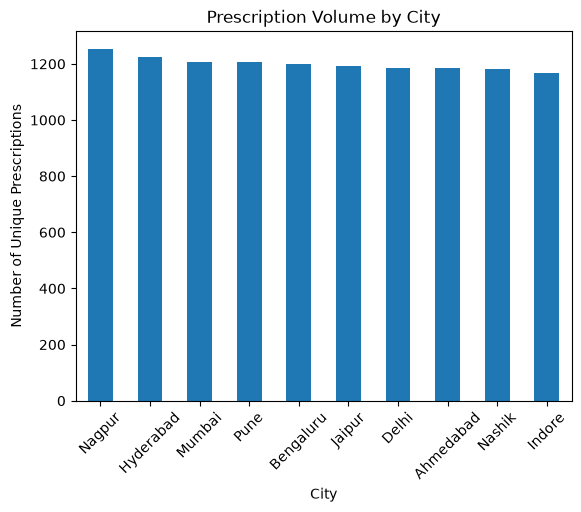

In [53]:
# Prescription volume by city

city_volume.plot(kind="bar")
plt.xlabel("City")
plt.ylabel("Number of Unique Prescriptions")
plt.title("Prescription Volume by City")
plt.xticks(rotation=45)
plt.show()

In [54]:
# 10. Which cities generate the highest total medicine expenditure, and do high-volume cities also have the highest expenditure?

city_cost = df.groupby("City").agg(
    Total_Expenditure=("Total_Medicine_Cost", "sum"),
    Prescriptions=("Prescription_ID", "nunique")
).assign(
    Average_Cost=lambda x: x["Total_Expenditure"] / x["Prescriptions"]
).sort_values("Total_Expenditure", ascending=False)

print("City-wise expenditure, prescription volume and average cost:")
print(city_cost)

print("\nCity with the highest expenditure:", city_cost.index[0])
print("Total expenditure:", round(city_cost.iloc[0]["Total_Expenditure"], 2))

print("\nCity with the highest prescription volume:", city_cost["Prescriptions"].idxmax())
print("Number of prescriptions:", city_cost["Prescriptions"].max())

City-wise expenditure, prescription volume and average cost:
           Total_Expenditure  Prescriptions  Average_Cost
City                                                     
Nagpur            7223000.43           1254   5759.968445
Hyderabad         6806004.27           1223   5565.007580
Mumbai            6797635.15           1208   5627.181416
Delhi             6715855.68           1187   5657.839663
Jaipur            6580520.64           1191   5525.206247
Bengaluru         6542067.86           1199   5456.270108
Ahmedabad         6537054.85           1185   5516.501983
Pune              6517409.71           1206   5404.153988
Indore            6463850.57           1166   5543.611123
Nashik            6418201.04           1181   5434.547875

City with the highest expenditure: Nagpur
Total expenditure: 7223000.43

City with the highest prescription volume: Nagpur
Number of prescriptions: 1254


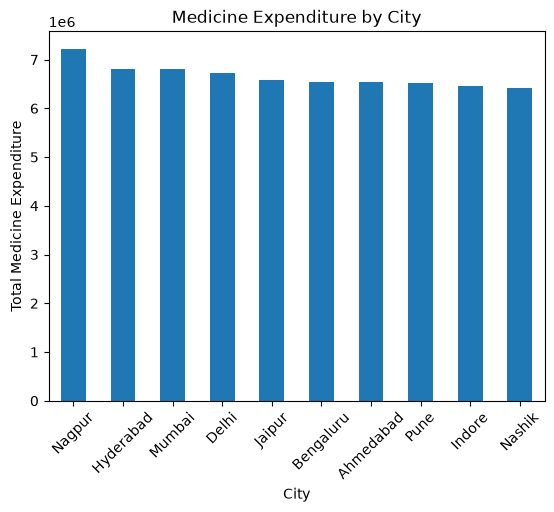

In [55]:
# Total medicine expenditure by city

city_cost["Total_Expenditure"].sort_values(ascending=False).plot(kind="bar")
plt.xlabel("City")
plt.ylabel("Total Medicine Expenditure")
plt.title("Medicine Expenditure by City")
plt.xticks(rotation=45)
plt.show()

In [56]:
# 11. Which cities have the highest average prescription cost, and how does this differ from their overall prescription volume?

city_cost = df.groupby("City").agg(
    Total_Cost=("Total_Medicine_Cost", "sum"),
    Prescriptions=("Prescription_ID", "nunique")
).assign(
    Average_Cost=lambda x: x["Total_Cost"] / x["Prescriptions"]
).sort_values("Average_Cost", ascending=False)

print("Average prescription cost by city:")
print(city_cost)

print("\nCity with the highest average prescription cost:", city_cost.index[0])
print("Average prescription cost:", round(city_cost.iloc[0]["Average_Cost"], 2))

Average prescription cost by city:
           Total_Cost  Prescriptions  Average_Cost
City                                              
Nagpur     7223000.43           1254   5759.968445
Delhi      6715855.68           1187   5657.839663
Mumbai     6797635.15           1208   5627.181416
Hyderabad  6806004.27           1223   5565.007580
Indore     6463850.57           1166   5543.611123
Jaipur     6580520.64           1191   5525.206247
Ahmedabad  6537054.85           1185   5516.501983
Bengaluru  6542067.86           1199   5456.270108
Nashik     6418201.04           1181   5434.547875
Pune       6517409.71           1206   5404.153988

City with the highest average prescription cost: Nagpur
Average prescription cost: 5759.97


Prescription count by city and department:
Department  Cardiology  Dermatology  ENT  Endocrinology  Gastroenterology  \
City                                                                        
Ahmedabad          127           78  117            118                74   
Bengaluru          114          100  108            117                97   
Delhi              142           94  114            124                96   
Hyderabad          122          105  123            123                88   
Indore             112          102  136            119                79   
Jaipur             131           96  112            125                73   
Mumbai             125           75  110            119                86   
Nagpur             124           94  119            130                90   
Nashik             120          107  115            118                82   
Pune               121           90  137            108                89   

Department  General Medicine  Or

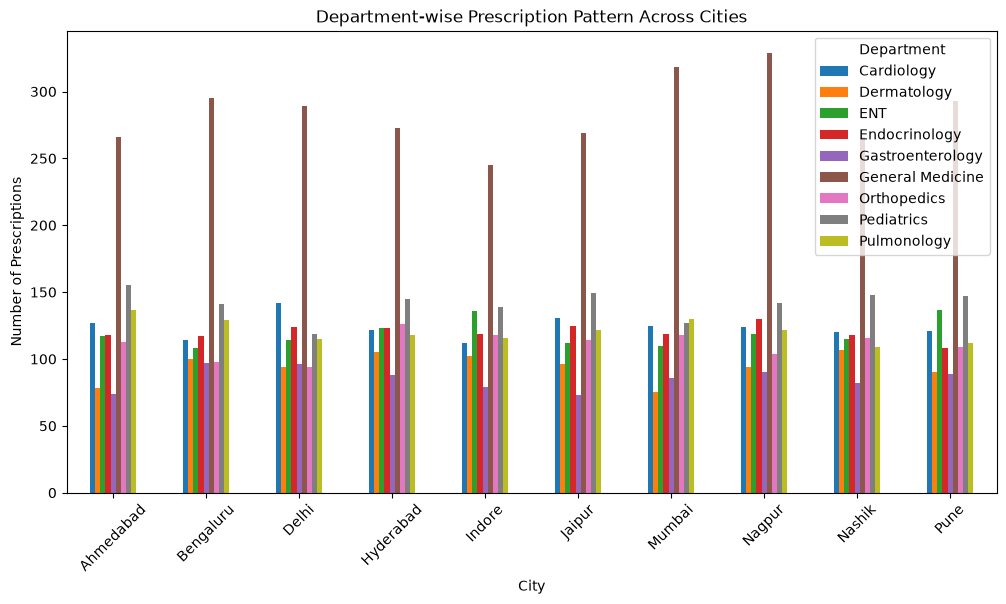

In [57]:
# 12. How does the department-wise prescription pattern vary from one city to another?

city_department = df.groupby(["City", "Department"])["Prescription_ID"].nunique().unstack()

print("Prescription count by city and department:")
print(city_department)

city_department.plot(kind="bar", figsize=(12, 6))
plt.xlabel("City")
plt.ylabel("Number of Prescriptions")
plt.title("Department-wise Prescription Pattern Across Cities")
plt.xticks(rotation=45)
plt.show()

In [58]:
# 13. Which city and department combinations contribute the most to overall prescription volume?

city_department_volume = df.groupby(["City", "Department"])["Prescription_ID"].nunique().sort_values(ascending=False)

print("Top 10 city and department combinations by prescription volume:")
print(city_department_volume.head(10))

Top 10 city and department combinations by prescription volume:
City       Department      
Nagpur     General Medicine    329
Mumbai     General Medicine    318
Bengaluru  General Medicine    295
Pune       General Medicine    293
Delhi      General Medicine    289
Hyderabad  General Medicine    273
Jaipur     General Medicine    269
Nashik     General Medicine    266
Ahmedabad  General Medicine    266
Indore     General Medicine    245
Name: Prescription_ID, dtype: int64


In [59]:
# 14. Which city and department combinations generate the highest medicine expenditure?

city_department_cost = df.groupby(["City", "Department"])["Total_Medicine_Cost"].sum().sort_values(ascending=False)

print("Top 10 city and department combinations by medicine expenditure:")
print(city_department_cost.head(10))

Top 10 city and department combinations by medicine expenditure:
City       Department      
Nagpur     General Medicine    2044139.98
Mumbai     General Medicine    1873655.44
Delhi      General Medicine    1763890.71
Pune       General Medicine    1723541.35
Bengaluru  General Medicine    1711724.08
Hyderabad  General Medicine    1688227.97
Ahmedabad  General Medicine    1636324.80
Jaipur     General Medicine    1618660.77
Nashik     General Medicine    1567943.62
Indore     General Medicine    1551069.31
Name: Total_Medicine_Cost, dtype: float64


In [60]:
# 15. How does prescription volume differ across age groups, and which age group receives the largest share of prescriptions?

age_volume = df.groupby("Age_Group")["Prescription_ID"].nunique().sort_values(ascending=False)

print("Prescription volume by age group:")
print(age_volume)

print("\nAge group with the highest prescription volume:", age_volume.index[0])
print("Number of prescriptions:", age_volume.iloc[0])

print("\nPercentage share of the highest age group:", round(age_volume.iloc[0] / age_volume.sum() * 100, 2), "%")

Prescription volume by age group:
Age_Group
Adult           3131
Young Adult     2837
Child           2086
Senior Adult    1955
Elderly         1200
Teen             791
Name: Prescription_ID, dtype: int64

Age group with the highest prescription volume: Adult
Number of prescriptions: 3131

Percentage share of the highest age group: 26.09 %


In [61]:
# 16. Which age group generates the highest total medicine expenditure?

age_expenditure = df.groupby("Age_Group")["Total_Medicine_Cost"].sum().sort_values(ascending=False)

print("Total medicine expenditure by age group:")
print(age_expenditure)

print("\nAge group with the highest expenditure:", age_expenditure.index[0])
print("Total expenditure:", round(age_expenditure.iloc[0], 2))

Total medicine expenditure by age group:
Age_Group
Adult           18801846.87
Young Adult     16393563.25
Senior Adult    12488003.90
Elderly          7758898.04
Child            7363138.79
Teen             3796149.35
Name: Total_Medicine_Cost, dtype: float64

Age group with the highest expenditure: Adult
Total expenditure: 18801846.87


In [62]:
# 17. How does average prescription cost vary across age groups?

age_cost = df.groupby("Age_Group").agg(
    Total_Cost=("Total_Medicine_Cost", "sum"),
    Prescriptions=("Prescription_ID", "nunique")
).assign(
    Average_Cost=lambda x: x["Total_Cost"] / x["Prescriptions"]
).sort_values("Average_Cost", ascending=False)

print("Average prescription cost by age group:")
print(age_cost)

Average prescription cost by age group:
               Total_Cost  Prescriptions  Average_Cost
Age_Group                                             
Elderly        7758898.04           1200   6465.748367
Senior Adult  12488003.90           1955   6387.725780
Adult         18801846.87           3131   6005.061281
Young Adult   16393563.25           2837   5778.485460
Teen           3796149.35            791   4799.177434
Child          7363138.79           2086   3529.788490


In [63]:
# 18. Does the average number of medicines per prescription increase or decrease across age groups?

age_medicine_count = df.groupby(["Age_Group", "Prescription_ID"])["Medicine_Name"].nunique().groupby("Age_Group").mean().sort_values(ascending=False)

print("Average number of medicines per prescription by age group:")
print(age_medicine_count)

Average number of medicines per prescription by age group:
Age_Group
Senior Adult    3.240409
Elderly         3.236667
Adult           3.046311
Young Adult     2.984843
Teen            2.829330
Child           2.671141
Name: Medicine_Name, dtype: float64


In [7]:
# 19. Which diagnoses are most common within each age group?

age_diagnosis = df.groupby(["Age_Group", "Diagnosis"])["Prescription_ID"].nunique().reset_index()

most_common_age_diagnosis = age_diagnosis.loc[age_diagnosis.groupby("Age_Group")["Prescription_ID"].idxmax()].sort_values("Age_Group")

print("Most common diagnosis within each age group:")
print(most_common_age_diagnosis)

Most common diagnosis within each age group:
        Age_Group           Diagnosis  Prescription_ID
10          Adult         Common Cold              196
58          Child  Pediatric Diarrhea              376
87        Elderly       Heart Failure              140
112  Senior Adult         Common Cold              125
160          Teen  Pediatric Diarrhea               62
180   Young Adult         Common Cold              211


In [65]:
# 20. Which medicine categories are most frequently prescribed within each age group?

age_category = df.groupby(["Age_Group", "Medicine_Category"])["Prescription_ID"].nunique().reset_index()

most_common_age_category = age_category.loc[age_category.groupby("Age_Group")["Prescription_ID"].idxmax()].sort_values("Age_Group")

print("Most frequently prescribed medicine category within each age group:")
print(most_common_age_category)

Most frequently prescribed medicine category within each age group:
        Age_Group     Medicine_Category  Prescription_ID
32          Adult    Vitamin/Supplement              934
56          Child  Pediatric Supplement              801
92        Elderly                Statin              374
131  Senior Adult    Vitamin/Supplement              642
164          Teen    Vitamin/Supplement              179
197   Young Adult    Vitamin/Supplement              898


Prescription volume, medicine quantity and expenditure by gender:
        Prescriptions  Total_Quantity  Total_Expenditure
Gender                                                  
Male             6066          144895        33826947.70
Female           5810          137638        32073532.64
Other             124            2982          701119.86


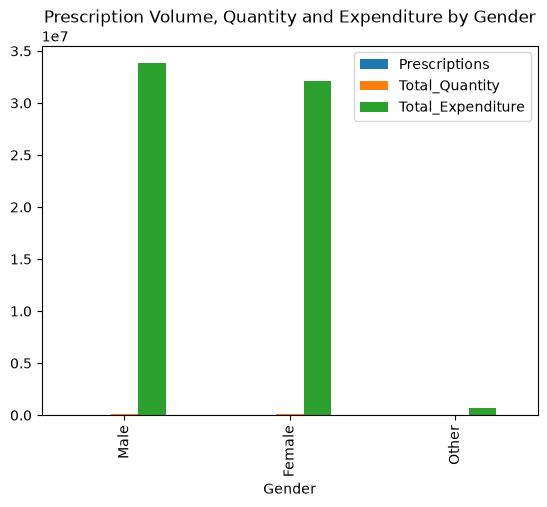

In [66]:
# 21. How do prescription volume, medicine quantity, and expenditure differ across genders?

gender_analysis = df.groupby("Gender").agg(
    Prescriptions=("Prescription_ID", "nunique"),
    Total_Quantity=("Quantity", "sum"),
    Total_Expenditure=("Total_Medicine_Cost", "sum")
).sort_values("Prescriptions", ascending=False)

print("Prescription volume, medicine quantity and expenditure by gender:")
print(gender_analysis)

gender_analysis.plot(kind="bar")
plt.title("Prescription Volume, Quantity and Expenditure by Gender")
plt.xlabel("Gender")
plt.show()

In [67]:
# 22. Are particular diagnoses more common for one gender than another?

gender_diagnosis = df.groupby(["Gender", "Diagnosis"])["Prescription_ID"].nunique().reset_index()

most_common_gender_diagnosis = gender_diagnosis.loc[gender_diagnosis.groupby("Gender")["Prescription_ID"].idxmax()]

print("Most common diagnosis for each gender:")
print(most_common_gender_diagnosis)

Most common diagnosis for each gender:
    Gender    Diagnosis  Prescription_ID
10  Female  Common Cold              322
48    Male  Common Cold              324
84   Other   Bronchitis                8


Most frequently prescribed medicine category for each gender:
    Gender   Medicine_Category  Prescription_ID
32  Female  Vitamin/Supplement             1549
65    Male  Vitamin/Supplement             1618
68   Other         Antacid/PPI               30


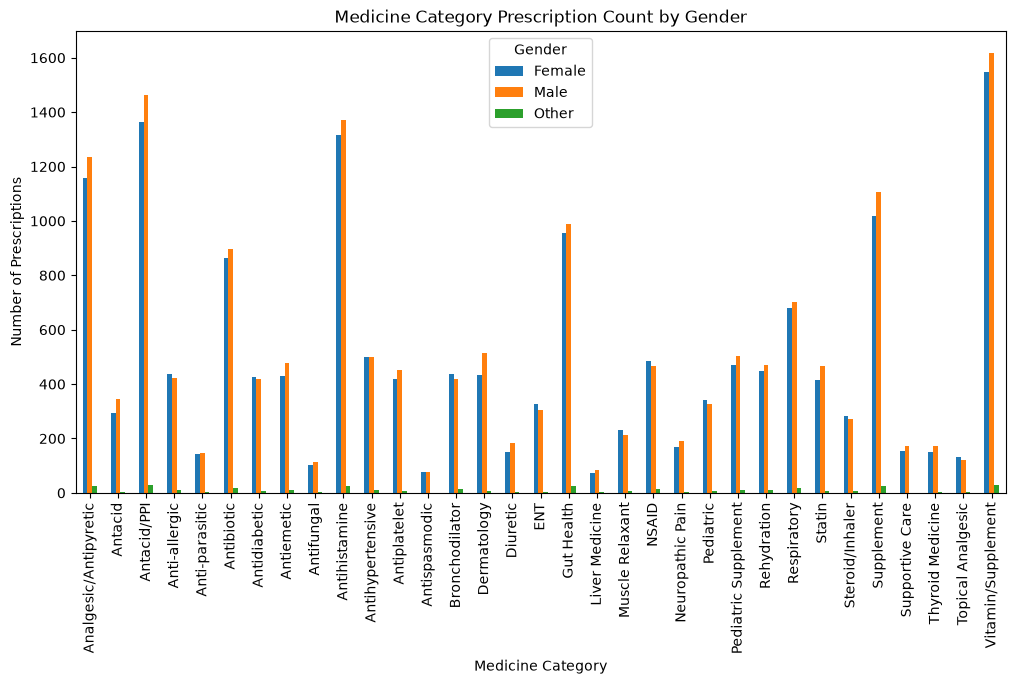

In [68]:
# 23. Do the medicine categories prescribed differ noticeably across genders?

gender_category = df.groupby(["Gender", "Medicine_Category"])["Prescription_ID"].nunique().reset_index()

most_common_gender_category = gender_category.loc[gender_category.groupby("Gender")["Prescription_ID"].idxmax()]

print("Most frequently prescribed medicine category for each gender:")
print(most_common_gender_category)

gender_category.pivot(index="Medicine_Category", columns="Gender", values="Prescription_ID").plot(kind="bar", figsize=(12,6))
plt.title("Medicine Category Prescription Count by Gender")
plt.xlabel("Medicine Category")
plt.ylabel("Number of Prescriptions")
plt.xticks(rotation=90)
plt.show()

Average prescription cost by age group and gender:
                     Total_Cost  Prescriptions  Average_Cost
Age_Group    Gender                                         
Adult        Female  9074874.11           1515   5990.015914
             Male    9517074.56           1584   6008.254141
             Other    209898.20             32   6559.318750
Child        Female  3520982.26           1026   3431.756589
             Male    3763461.99           1041   3615.237262
             Other     78694.54             19   4141.817895
Elderly      Female  3653188.60            571   6397.878459
             Male    4038534.53            619   6524.288417
             Other     67174.91             10   6717.491000
Senior Adult Female  6098518.29            951   6412.742681
             Male    6259427.54            980   6387.170959
             Other    130058.07             24   5419.086250
Teen         Female  1815938.43            370   4907.941703
             Male    1912639.46   

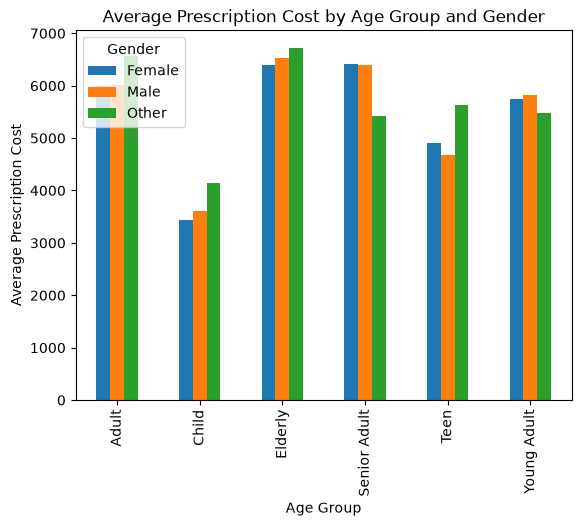

In [69]:
# 24. How does average prescription cost vary by gender within each age group?

gender_age_cost = df.groupby(["Age_Group", "Gender"]).agg(
    Total_Cost=("Total_Medicine_Cost", "sum"),
    Prescriptions=("Prescription_ID", "nunique")
).assign(
    Average_Cost=lambda x: x["Total_Cost"] / x["Prescriptions"]
)

print("Average prescription cost by age group and gender:")
print(gender_age_cost)

gender_age_cost["Average_Cost"].unstack().plot(kind="bar")
plt.title("Average Prescription Cost by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Average Prescription Cost")
plt.show()

In [70]:
# 25. Which medicines are prescribed most frequently, and how concentrated is prescription activity among the leading medicines?

medicine_frequency = df.groupby("Medicine_Name")["Prescription_ID"].nunique().sort_values(ascending=False)

print("Top 10 medicines by number of prescriptions:")
print(medicine_frequency.head(10))

print("\nPercentage of prescriptions accounted for by the top 5 medicines:", round(medicine_frequency.head(5).sum() / df["Prescription_ID"].nunique() * 100, 2), "%")

Top 10 medicines by number of prescriptions:
Medicine_Name
Pantoprazole    2777
Cetirizine      2617
Paracetamol     2326
Probiotic       1958
Cough Syrup     1386
Azithromycin    1319
Vitamin C       1150
Vitamin B12     1089
Vitamin D3      1015
Calcium          995
Name: Prescription_ID, dtype: int64

Percentage of prescriptions accounted for by the top 5 medicines: 92.2 %


In [71]:
# 26. Which medicines have the highest total quantity prescribed?

medicine_quantity = df.groupby("Medicine_Name")["Quantity"].sum().sort_values(ascending=False)

print("Top 10 medicines by total quantity prescribed:")
print(medicine_quantity.head(10))

Top 10 medicines by total quantity prescribed:
Medicine_Name
Pantoprazole    25099
Cetirizine      23724
Paracetamol     21105
Probiotic       17797
Azithromycin    11917
Vitamin C       10374
Vitamin B12      9929
Calcium          9059
Vitamin D3       9036
Telmisartan      8591
Name: Quantity, dtype: int64


In [72]:
# 27. Which medicines generate the highest total medicine expenditure?

medicine_expenditure = df.groupby("Medicine_Name")["Total_Medicine_Cost"].sum().sort_values(ascending=False)

print("Top 10 medicines by total medicine expenditure:")
print(medicine_expenditure.head(10))

Top 10 medicines by total medicine expenditure:
Medicine_Name
Pantoprazole    5910083.96
Cetirizine      5477082.51
Paracetamol     4980508.54
Probiotic       4215731.70
Azithromycin    2747597.14
Vitamin C       2384985.14
Vitamin B12     2292292.28
Calcium         2137414.10
Vitamin D3      2085714.57
Atorvastatin    1943886.27
Name: Total_Medicine_Cost, dtype: float64


In [73]:
# 28. Do the most frequently prescribed medicines also generate the highest expenditure?

medicine_analysis = df.groupby("Medicine_Name").agg(
    Prescriptions=("Prescription_ID", "nunique"),
    Total_Expenditure=("Total_Medicine_Cost", "sum")
).sort_values("Prescriptions", ascending=False)

print("Top medicines by prescription frequency:")
print(medicine_analysis.head(10))

print("\nTop medicines by expenditure:")
print(medicine_analysis.sort_values("Total_Expenditure", ascending=False).head(10))

Top medicines by prescription frequency:
               Prescriptions  Total_Expenditure
Medicine_Name                                  
Pantoprazole            2777         5910083.96
Cetirizine              2617         5477082.51
Paracetamol             2326         4980508.54
Probiotic               1958         4215731.70
Cough Syrup             1386          631709.66
Azithromycin            1319         2747597.14
Vitamin C               1150         2384985.14
Vitamin B12             1089         2292292.28
Vitamin D3              1015         2085714.57
Calcium                  995         2137414.10

Top medicines by expenditure:
               Prescriptions  Total_Expenditure
Medicine_Name                                  
Pantoprazole            2777         5910083.96
Cetirizine              2617         5477082.51
Paracetamol             2326         4980508.54
Probiotic               1958         4215731.70
Azithromycin            1319         2747597.14
Vitamin C       

Medicines with high average unit price and their prescription frequency:
                      Average_Unit_Price  Prescriptions
Medicine_Name                                          
VITAMIN B COMPLEX             348.390000              2
FUROSEMIDE                    327.476667              3
PARACETAMOL SYRUP             309.536667              6
CLOPIDOGREL                   299.555000              2
URSODEOXYCHOLIC ACID          289.020000              2
PAIN RELIEF GEL               284.160000              2
MUSCLE RELAXANT               282.655000              4
CALCIUM                       279.025000              2
AZITHROMYCIN                  277.503750              8
NASAL SPRAY                   271.602222              9


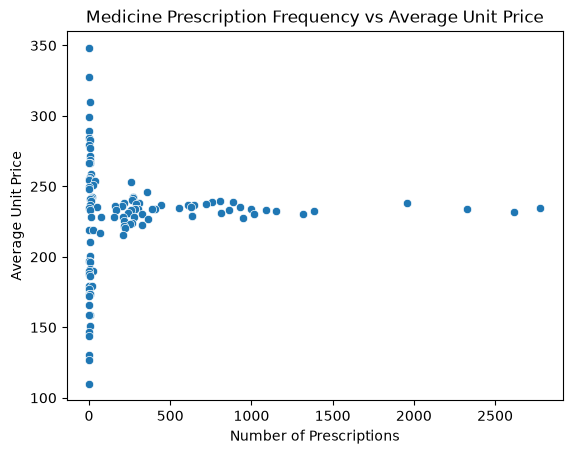

In [74]:
# 29. Which medicines have high unit prices but relatively low prescription frequency?

medicine_price_frequency = df.groupby("Medicine_Name").agg(
    Average_Unit_Price=("Unit_Price", "mean"),
    Prescriptions=("Prescription_ID", "nunique")
).sort_values("Average_Unit_Price", ascending=False)

print("Medicines with high average unit price and their prescription frequency:")
print(medicine_price_frequency.head(10))

sns.scatterplot(data=medicine_price_frequency, x="Prescriptions", y="Average_Unit_Price")
plt.title("Medicine Prescription Frequency vs Average Unit Price")
plt.xlabel("Number of Prescriptions")
plt.ylabel("Average Unit Price")
plt.show()

In [75]:
# 30. Which medicines have low unit prices but generate high expenditure because of large quantities or frequent use?

medicine_analysis = df.groupby("Medicine_Name").agg(
    Average_Unit_Price=("Unit_Price", "mean"),
    Total_Quantity=("Quantity", "sum"),
    Prescriptions=("Prescription_ID", "nunique"),
    Total_Expenditure=("Total_Medicine_Cost", "sum")
)

low_price_medicines = medicine_analysis[medicine_analysis["Average_Unit_Price"] <= medicine_analysis["Average_Unit_Price"].median()].sort_values("Total_Expenditure", ascending=False)

print("Low-priced medicines with the highest total expenditure:")
print(low_price_medicines.head(10))

Low-priced medicines with the highest total expenditure:
               Average_Unit_Price  Total_Quantity  Prescriptions  \
Medicine_Name                                                      
Cetirizine             231.865415           23724           2617   
Azithromycin           230.231077           11917           1319   
Vitamin C              232.683548           10374           1150   
Vitamin B12            233.463646            9929           1089   
Vitamin D3             230.393123            9036           1015   
Telmisartan            227.553084            8591            950   
Montelukast            232.951279            7763            860   
Salbutamol             231.377187            7435            814   
Zinc                   228.983791            5807            633   
Glimepiride            226.828370            3319            362   

               Total_Expenditure  
Medicine_Name                     
Cetirizine            5477082.51  
Azithromycin         

In [76]:
# 31. Which medicine categories account for the largest share of prescription records?

category_counts = df.groupby("Medicine_Category")["Prescription_ID"].nunique().sort_values(ascending=False)

print("Top medicine category:", category_counts.index[0])
print("Number of prescriptions:", category_counts.iloc[0])
print("Percentage share:", round(category_counts.iloc[0] / df["Prescription_ID"].nunique() * 100, 2), "%")

Top medicine category: Vitamin/Supplement
Number of prescriptions: 3197
Percentage share: 26.64 %


In [77]:
# 32. Which medicine categories generate the highest total expenditure?

category_expenditure = df.groupby("Medicine_Category")["Total_Medicine_Cost"].sum().sort_values(ascending=False)

print("Category with the highest expenditure:", category_expenditure.index[0])
print("Total expenditure:", round(category_expenditure.iloc[0], 2))

Category with the highest expenditure: Vitamin/Supplement
Total expenditure: 7197629.1


In [78]:
# 33. Which medicine categories have the highest average unit price?

category_price = df.groupby("Medicine_Category")["Unit_Price"].mean().sort_values(ascending=False)

print("Category with the highest average unit price:", category_price.index[0])
print("Average unit price:", round(category_price.iloc[0], 2))

Category with the highest average unit price: Neuropathic Pain
Average unit price: 245.92


In [79]:
# 34. Which medicine categories have the highest average quantity per prescription record?

category_quantity = df.groupby("Medicine_Category")["Quantity"].mean().sort_values(ascending=False)

print("Category with the highest average quantity:", category_quantity.index[0])
print("Average quantity:", round(category_quantity.iloc[0], 2))

Category with the highest average quantity: Statin
Average quantity: 9.3


In [80]:
# 35. Which medicine categories show the greatest variation in total medicine cost?

category_cost = df.groupby("Medicine_Category")["Total_Medicine_Cost"].std().sort_values(ascending=False)

print("Category with the greatest cost variation:", category_cost.index[0])
print("Standard deviation of cost:", round(category_cost.iloc[0], 2))

Category with the greatest cost variation: NSAID
Standard deviation of cost: 1550.86


Most strongly associated medicine category for each diagnosis:
                   Diagnosis      Medicine_Category  Prescription_ID
0                Acid Reflux                Antacid              178
19                      Acne             Antibiotic              190
43         Allergic Rhinitis                    ENT              307
69                    Anemia     Vitamin/Supplement              273
73                    Asthma          Anti-allergic              299
102                Back Pain                  NSAID              219
109      Bacterial Infection  Analgesic/Antipyretic              337
143                Body Pain                  NSAID              226
163               Bronchitis             Gut Health              277
179                     COPD         Bronchodilator              272
189              Common Cold  Analgesic/Antipyretic              578
223  Coronary Artery Disease           Antiplatelet              297
239      Diabetic Neuropathy           A

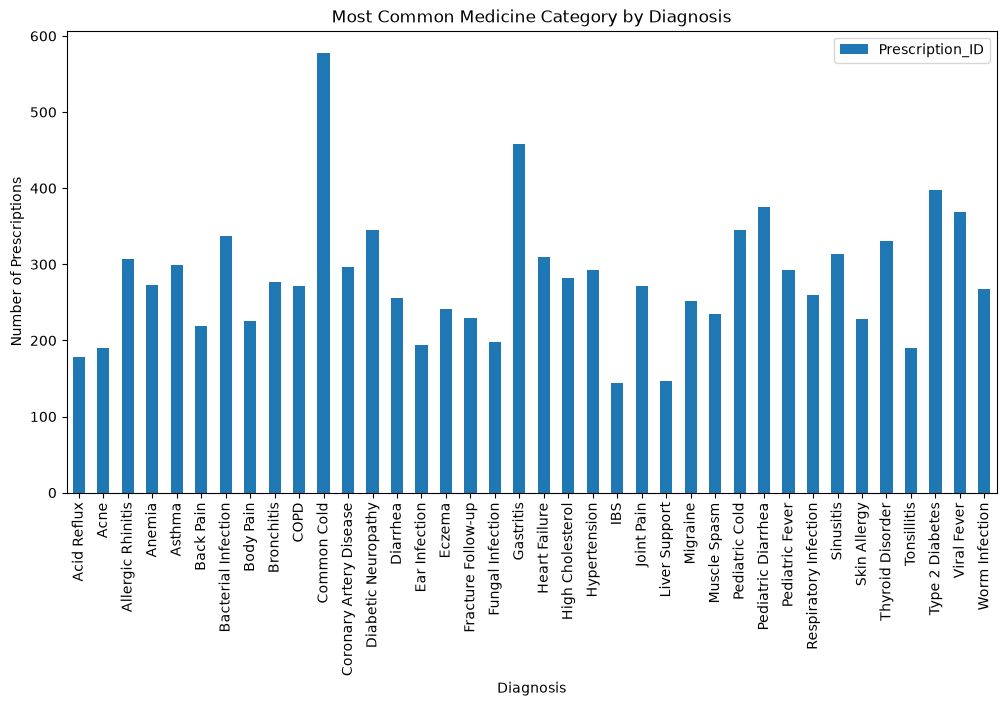

In [81]:
# 36. Which medicine category is most strongly associated with each diagnosis?

diagnosis_category = df.groupby(["Diagnosis", "Medicine_Category"])["Prescription_ID"].nunique().reset_index()
strongest_category = diagnosis_category.loc[diagnosis_category.groupby("Diagnosis")["Prescription_ID"].idxmax()]

print("Most strongly associated medicine category for each diagnosis:")
print(strongest_category[["Diagnosis", "Medicine_Category", "Prescription_ID"]])

# Most common medicine category for each diagnosis

strongest_category.plot(x="Diagnosis", y="Prescription_ID", kind="bar", figsize=(12,6))
plt.xlabel("Diagnosis")
plt.ylabel("Number of Prescriptions")
plt.title("Most Common Medicine Category by Diagnosis")
plt.xticks(rotation=90)
plt.show()

Most frequently prescribed medicine for each diagnosis:
                    Diagnosis            Medicine_Name  Prescription_ID
1                 Acid Reflux              Antacid Gel              176
32                       Acne              Doxycycline              190
60          Allergic Rhinitis              Montelukast              304
100                    Anemia              Vitamin B12              240
135                    Asthma               Salbutamol              295
150                 Back Pain               Diclofenac              217
195       Bacterial Infection             Pantoprazole              329
220                 Body Pain                Ibuprofen              224
249                Bronchitis              Cough Syrup              275
273                      COPD               Budesonide              243
327               Common Cold              Paracetamol              564
348   Coronary Artery Disease             Atorvastatin              264
396     

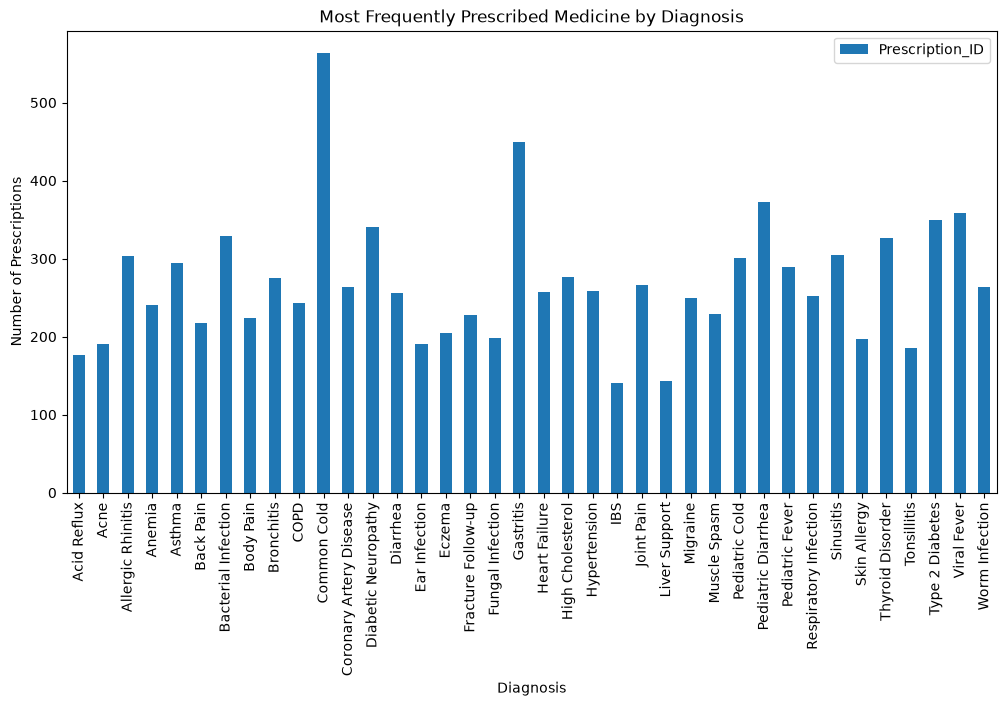

In [82]:
# 37. What is the most frequently prescribed medicine for each diagnosis?

diagnosis_medicine = df.groupby(["Diagnosis", "Medicine_Name"])["Prescription_ID"].nunique().reset_index()
most_common_medicine = diagnosis_medicine.loc[diagnosis_medicine.groupby("Diagnosis")["Prescription_ID"].idxmax()]

print("Most frequently prescribed medicine for each diagnosis:")
print(most_common_medicine[["Diagnosis", "Medicine_Name", "Prescription_ID"]])

# Most frequently prescribed medicine for each diagnosis

most_common_medicine.plot(x="Diagnosis", y="Prescription_ID", kind="bar", figsize=(12,6))
plt.xlabel("Diagnosis")
plt.ylabel("Number of Prescriptions")
plt.title("Most Frequently Prescribed Medicine by Diagnosis")
plt.xticks(rotation=90)
plt.show()

Top 10 diagnosis and medicine category combinations:
Diagnosis           Medicine_Category    
Common Cold         Analgesic/Antipyretic    578
                    Respiratory              572
                    Antihistamine            571
                    Vitamin/Supplement       569
Gastritis           Antacid/PPI              458
                    Antiemetic               447
                    Antacid                  437
Type 2 Diabetes     Antidiabetic             397
Pediatric Diarrhea  Gut Health               375
Viral Fever         Analgesic/Antipyretic    369
Name: Prescription_ID, dtype: int64


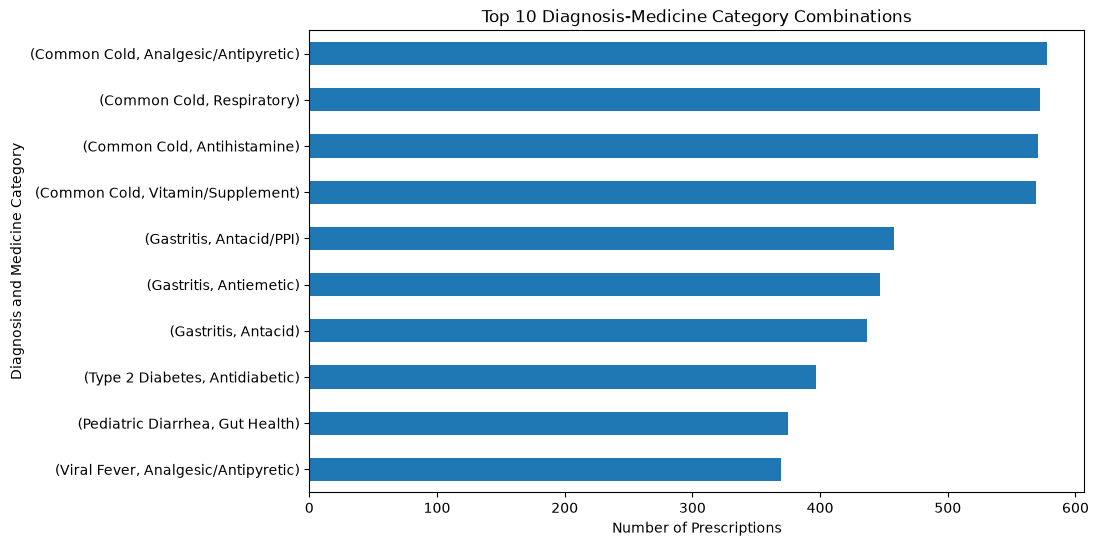

In [83]:
# 38. Which diagnosis and medicine category combinations occur most often?

diagnosis_category_count = df.groupby(["Diagnosis", "Medicine_Category"])["Prescription_ID"].nunique().sort_values(ascending=False)

print("Top 10 diagnosis and medicine category combinations:")
print(diagnosis_category_count.head(10))

# Top 10 diagnosis and medicine category combinations

diagnosis_category_count.head(10).sort_values().plot(kind="barh", figsize=(10,6))
plt.xlabel("Number of Prescriptions")
plt.ylabel("Diagnosis and Medicine Category")
plt.title("Top 10 Diagnosis-Medicine Category Combinations")
plt.show()


Diagnosis with the widest variety of medicines: Common Cold
Number of different medicines: 46
Number of different categories: 28


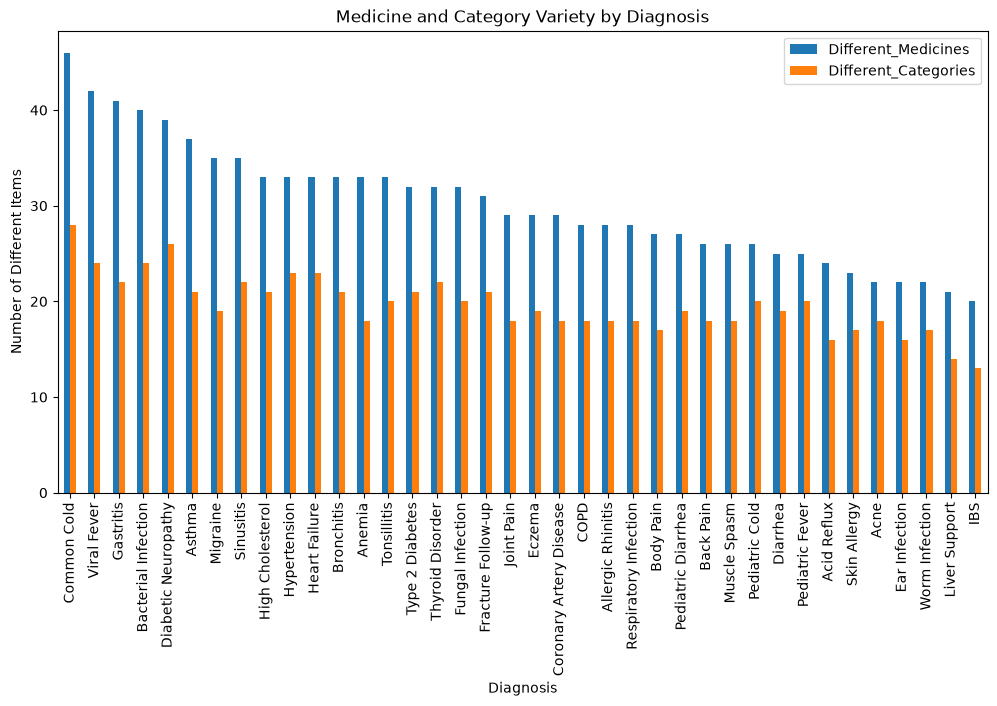

In [84]:
# 39. Which diagnoses involve the widest variety of medicines and medicine categories?

diagnosis_variety = df.groupby("Diagnosis").agg(
    Different_Medicines=("Medicine_Name", "nunique"),
    Different_Categories=("Medicine_Category", "nunique")
).sort_values("Different_Medicines", ascending=False)

print("Diagnosis with the widest variety of medicines:", diagnosis_variety.index[0])
print("Number of different medicines:", diagnosis_variety.iloc[0]["Different_Medicines"])
print("Number of different categories:", diagnosis_variety.iloc[0]["Different_Categories"])

# Variety of medicines and categories by diagnosis

diagnosis_variety.plot(kind="bar", figsize=(12,6))
plt.xlabel("Diagnosis")
plt.ylabel("Number of Different Items")
plt.title("Medicine and Category Variety by Diagnosis")
plt.xticks(rotation=90)
plt.show()

Diagnosis with the highest average prescription cost: Hypertension
Average prescription cost: 8142.92


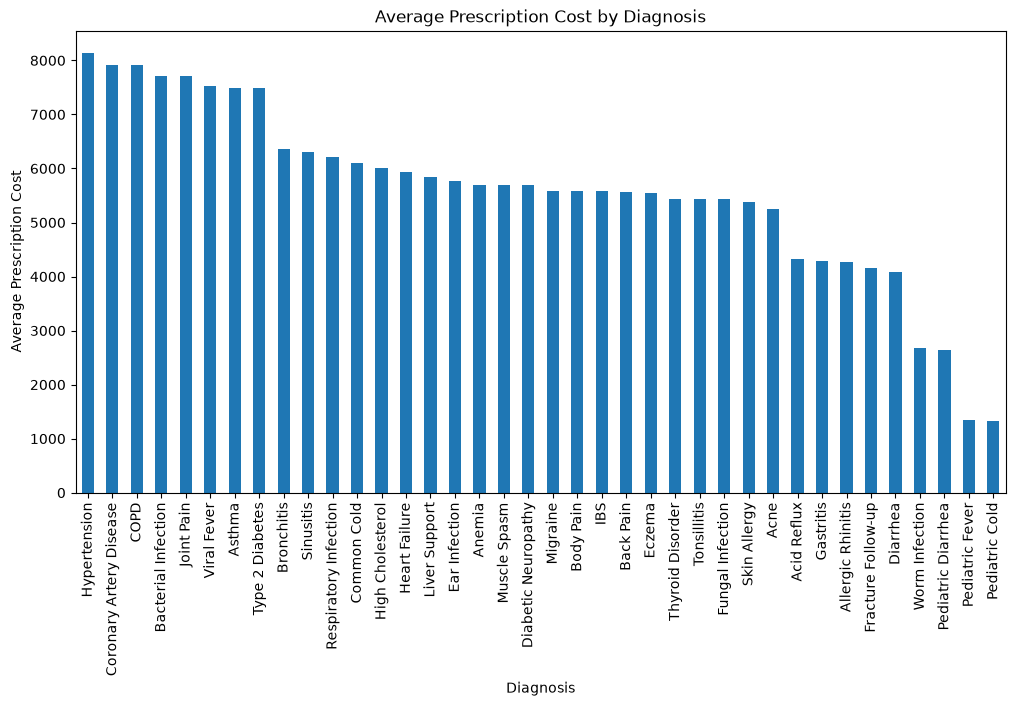

In [85]:
# 40. Which diagnoses have the highest average prescription cost?

diagnosis_cost = df.groupby("Diagnosis").agg(
    Total_Cost=("Total_Medicine_Cost", "sum"),
    Prescriptions=("Prescription_ID", "nunique")
).assign(
    Average_Cost=lambda x: x["Total_Cost"] / x["Prescriptions"]
).sort_values("Average_Cost", ascending=False)

print("Diagnosis with the highest average prescription cost:", diagnosis_cost.index[0])
print("Average prescription cost:", round(diagnosis_cost.iloc[0]["Average_Cost"], 2))

# Average prescription cost by diagnosis

diagnosis_cost["Average_Cost"].sort_values(ascending=False).plot(kind="bar", figsize=(12,6))
plt.xlabel("Diagnosis")
plt.ylabel("Average Prescription Cost")
plt.title("Average Prescription Cost by Diagnosis")
plt.xticks(rotation=90)
plt.show()

In [86]:
# 41. Which diagnoses generate high expenditure despite having relatively few prescriptions?

diagnosis_analysis = df.groupby("Diagnosis").agg(
    Prescriptions=("Prescription_ID", "nunique"),
    Total_Expenditure=("Total_Medicine_Cost", "sum")
).sort_values("Total_Expenditure", ascending=False)

print("Diagnoses with highest expenditure:")
print(diagnosis_analysis.head(10))

Diagnoses with highest expenditure:
                         Prescriptions  Total_Expenditure
Diagnosis                                                
Common Cold                        654         3985987.12
Viral Fever                        418         3149173.93
Type 2 Diabetes                    397         2970407.99
Bacterial Infection                378         2916390.17
Asthma                             341         2554346.04
Hypertension                       293         2385875.25
Coronary Artery Disease            297         2350852.83
Diabetic Neuropathy                407         2315089.64
Joint Pain                         300         2310882.14
Gastritis                          532         2286038.42


Number of prescriptions month by month:
Month
Apr    1462
Aug     755
Dec     801
Feb    1368
Jan    1545
Jul     781
Jun     732
Mar    1551
May     732
Nov     757
Oct     781
Sep     735
Name: Prescription_ID, dtype: int64


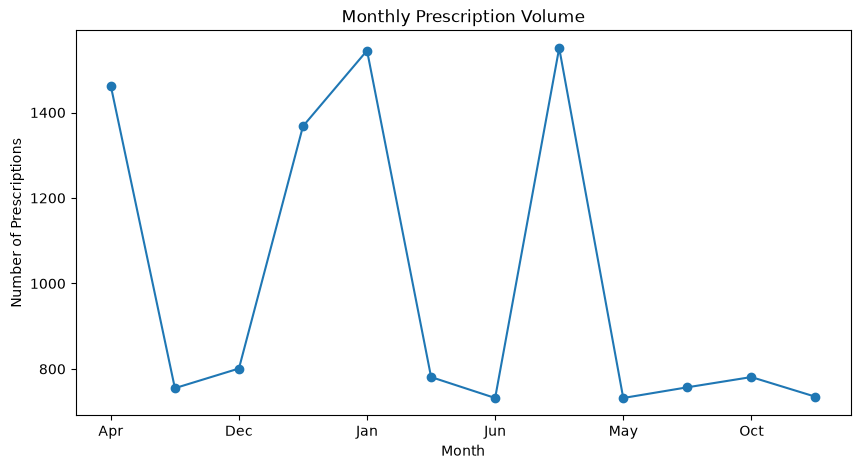

In [87]:
# 42. How does the number of prescriptions change month by month?

monthly_prescriptions = df.groupby("Month")["Prescription_ID"].nunique()

print("Number of prescriptions month by month:")
print(monthly_prescriptions)

monthly_prescriptions.plot(kind="line", marker="o", figsize=(10,5))
plt.xlabel("Month")
plt.ylabel("Number of Prescriptions")
plt.title("Monthly Prescription Volume")
plt.show()

In [88]:
# 43. Which months record the highest and lowest prescription volume?

monthly_prescriptions = df.groupby("Month")["Prescription_ID"].nunique()

print("Month with the highest prescription volume:", monthly_prescriptions.idxmax())
print("Highest number of prescriptions:", monthly_prescriptions.max())

print("\nMonth with the lowest prescription volume:", monthly_prescriptions.idxmin())
print("Lowest number of prescriptions:", monthly_prescriptions.min())

Month with the highest prescription volume: Mar
Highest number of prescriptions: 1551

Month with the lowest prescription volume: Jun
Lowest number of prescriptions: 732


Total medicine expenditure month by month:
Month
Apr    7903563.69
Aug    4276151.24
Dec    4325439.25
Feb    7637246.87
Jan    8594075.33
Jul    4558624.08
Jun    4008713.06
Mar    8513289.18
May    3974568.39
Nov    4157869.19
Oct    4526157.27
Sep    4125902.65
Name: Total_Medicine_Cost, dtype: float64


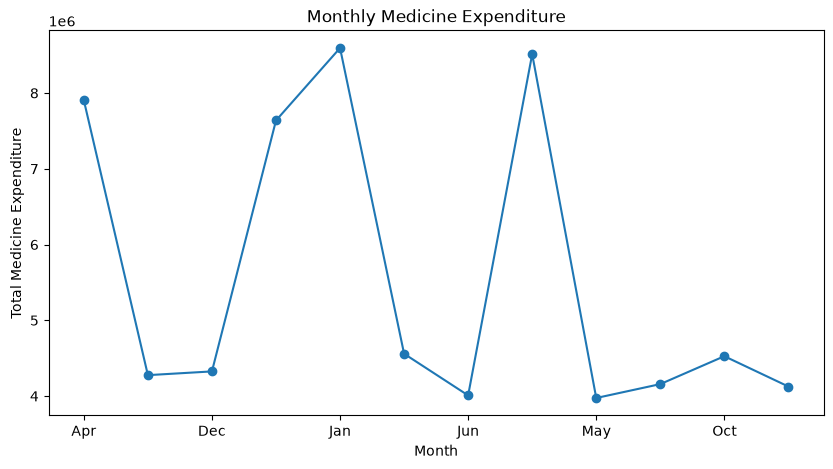

In [89]:
# 44. How does total medicine expenditure change month by month?

monthly_expenditure = df.groupby("Month")["Total_Medicine_Cost"].sum()

print("Total medicine expenditure month by month:")
print(monthly_expenditure)

monthly_expenditure.plot(kind="line", marker="o", figsize=(10,5))
plt.xlabel("Month")
plt.ylabel("Total Medicine Expenditure")
plt.title("Monthly Medicine Expenditure")
plt.show()

In [90]:
# 45. Which months have unusually high or low average prescription costs?

x = df.groupby("Month").agg(Total_Cost=("Total_Medicine_Cost", "sum"), Prescriptions=("Prescription_ID", "nunique")).assign(Average_Cost=lambda x: x["Total_Cost"] / x["Prescriptions"]).sort_values("Average_Cost", ascending=False)

print("Month with highest average prescription cost:", x.index[0])
print("Highest average cost:", round(x.iloc[0]["Average_Cost"], 2))

print("\nMonth with lowest average prescription cost:", x.index[-1])
print("Lowest average cost:", round(x.iloc[-1]["Average_Cost"], 2))

Month with highest average prescription cost: Jul
Highest average cost: 5836.91

Month with lowest average prescription cost: Dec
Lowest average cost: 5400.05


In [91]:
# 46. Do monthly prescription volume and monthly medicine expenditure follow the same pattern, or do they diverge in certain months?

monthly_pattern = df.groupby("Month").agg(
    Prescriptions=("Prescription_ID", "nunique"),
    Total_Expenditure=("Total_Medicine_Cost", "sum")
)

print("Monthly prescription volume and expenditure:")
print(monthly_pattern)


Monthly prescription volume and expenditure:
       Prescriptions  Total_Expenditure
Month                                  
Apr             1462         7903563.69
Aug              755         4276151.24
Dec              801         4325439.25
Feb             1368         7637246.87
Jan             1545         8594075.33
Jul              781         4558624.08
Jun              732         4008713.06
Mar             1551         8513289.18
May              732         3974568.39
Nov              757         4157869.19
Oct              781         4526157.27
Sep              735         4125902.65


Month-over-month prescription and expenditure changes:
       Prescriptions  Expenditure  Prescription_Change  Expenditure_Change
Month                                                                     
Apr             1462   7903563.69                  NaN                 NaN
Aug              755   4276151.24               -707.0         -3627412.45
Dec              801   4325439.25                 46.0            49288.01
Feb             1368   7637246.87                567.0          3311807.62
Jan             1545   8594075.33                177.0           956828.46
Jul              781   4558624.08               -764.0         -4035451.25
Jun              732   4008713.06                -49.0          -549911.02
Mar             1551   8513289.18                819.0          4504576.12
May              732   3974568.39               -819.0         -4538720.79
Nov              757   4157869.19                 25.0           183300.80
Oct              781   4526157.27            

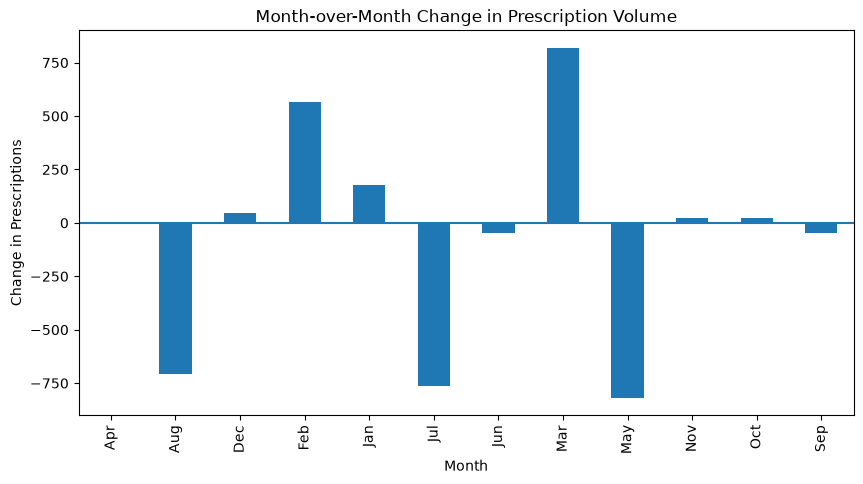

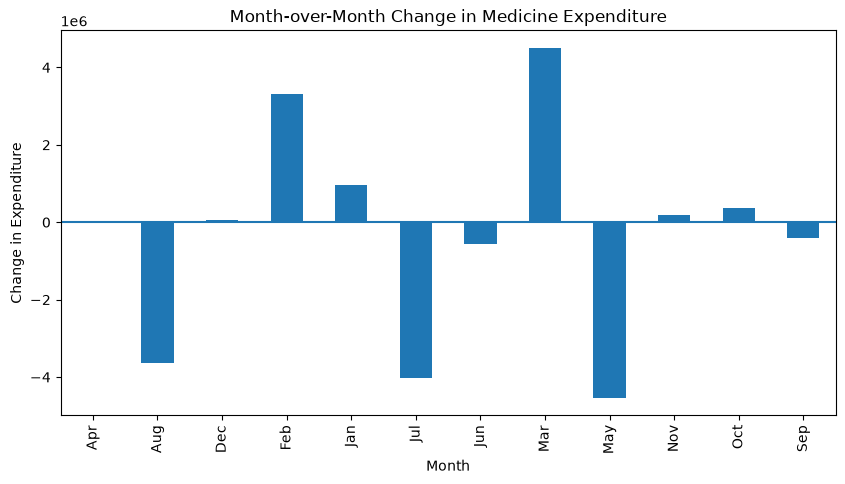

In [92]:
# 47. What month-over-month increases or decreases are visible in prescription volume and expenditure?

x = df.groupby("Month").agg(Prescriptions=("Prescription_ID", "nunique"), Expenditure=("Total_Medicine_Cost", "sum")).sort_index()

x["Prescription_Change"] = x["Prescriptions"].diff()
x["Expenditure_Change"] = x["Expenditure"].diff()

print("Month-over-month prescription and expenditure changes:")
print(x)

x["Prescription_Change"].plot(kind="bar", figsize=(10,5))
plt.xlabel("Month")
plt.ylabel("Change in Prescriptions")
plt.title("Month-over-Month Change in Prescription Volume")
plt.axhline(0)
plt.show()

x["Expenditure_Change"].plot(kind="bar", figsize=(10,5))
plt.xlabel("Month")
plt.ylabel("Change in Expenditure")
plt.title("Month-over-Month Change in Medicine Expenditure")
plt.axhline(0)
plt.show()

Prescription patterns across seasons:
         Prescriptions  Total_Quantity  Total_Expenditure
Season                                                   
Monsoon           3003           72696        16969391.03
Summer            4526          106863        24917578.53
Winter            4471          105956        24714630.64


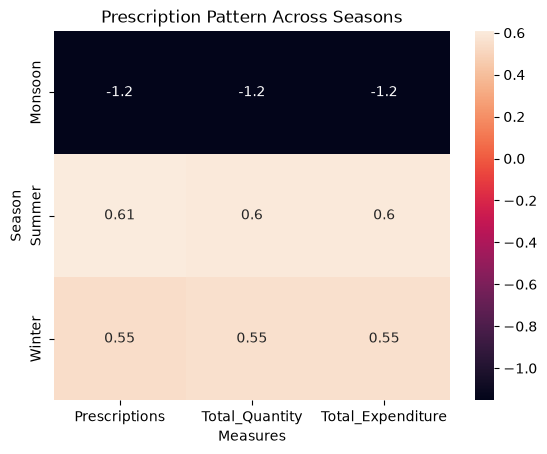

In [93]:
# 48. How do prescription patterns vary across Winter, Summer, and Monsoon?

season_analysis = df.groupby("Season").agg(
    Prescriptions=("Prescription_ID", "nunique"),
    Total_Quantity=("Quantity", "sum"),
    Total_Expenditure=("Total_Medicine_Cost", "sum")
)

print("Prescription patterns across seasons:")
print(season_analysis)

# Seasonal prescription pattern visualization

season_scaled = (season_analysis - season_analysis.mean()) / season_analysis.std()

sns.heatmap(season_scaled, annot=True)
plt.title("Prescription Pattern Across Seasons")
plt.xlabel("Measures")
plt.ylabel("Season")
plt.show()

In [94]:
# 49. Which season generates the highest prescription volume and medicine expenditure?

season_analysis = df.groupby("Season").agg(
    Prescriptions=("Prescription_ID", "nunique"),
    Total_Expenditure=("Total_Medicine_Cost", "sum")
)

highest_prescription_season = season_analysis["Prescriptions"].idxmax()
highest_expenditure_season = season_analysis["Total_Expenditure"].idxmax()

print("Season with the highest prescription volume:", highest_prescription_season)
print("Number of prescriptions:", season_analysis.loc[highest_prescription_season, "Prescriptions"])

print("\nSeason with the highest medicine expenditure:", highest_expenditure_season)
print("Total expenditure:", round(season_analysis.loc[highest_expenditure_season, "Total_Expenditure"], 2))

Season with the highest prescription volume: Summer
Number of prescriptions: 4526

Season with the highest medicine expenditure: Summer
Total expenditure: 24917578.53


In [95]:
# 50. Which diagnoses become more common during particular seasons?

season_diagnosis = df.groupby(["Season", "Diagnosis"])["Prescription_ID"].nunique().reset_index()

most_common_season_diagnosis = season_diagnosis.loc[season_diagnosis.groupby("Season")["Prescription_ID"].idxmax()].sort_values("Season")

print("Most common diagnosis within each season:")
print(most_common_season_diagnosis)


Most common diagnosis within each season:
     Season    Diagnosis  Prescription_ID
10  Monsoon  Common Cold              170
56   Summer    Gastritis              357
86   Winter  Common Cold              346


Medicine categories with the strongest seasonal pattern:
Medicine_Category
Antiemetic               2.587178
Antihistamine            2.575358
Gut Health               2.489912
Antacid                  2.341692
Antacid/PPI              2.068894
Analgesic/Antipyretic    2.019364
Respiratory              1.603598
Antibiotic               1.283348
Vitamin/Supplement       1.193329
Supplement               1.087829
Name: Prescription_Share, dtype: float64


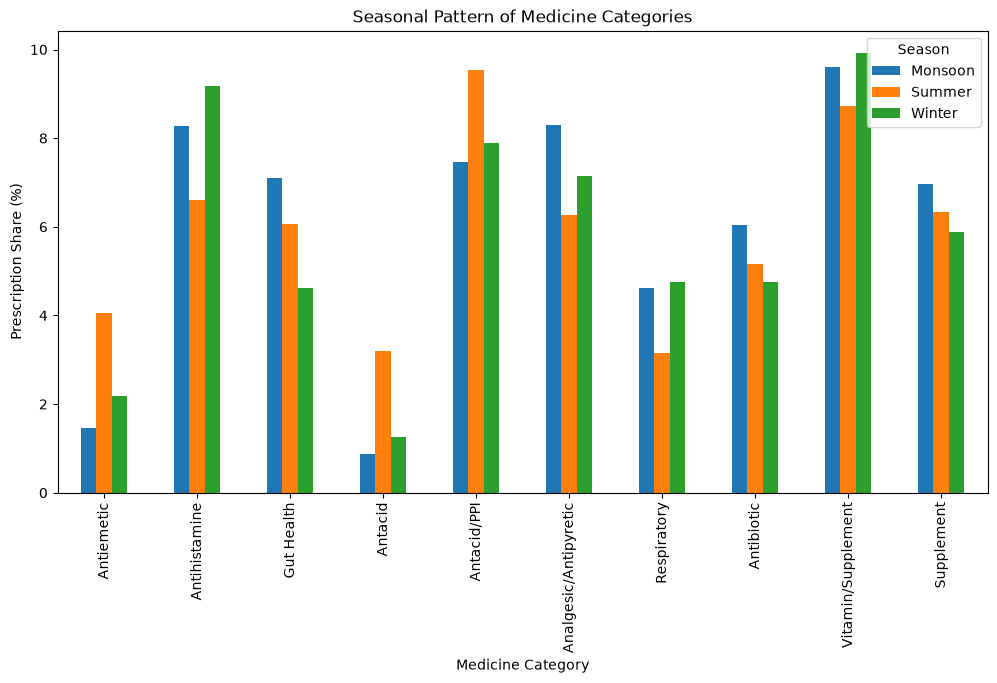

In [96]:
# 51. Which medicine categories show the strongest seasonal pattern?

season_category = df.groupby(["Season", "Medicine_Category"])["Prescription_ID"].nunique().reset_index()

season_category["Prescription_Share"] = season_category.groupby("Season")["Prescription_ID"].transform(lambda x: x / x.sum() * 100)

seasonal_variation = season_category.groupby("Medicine_Category")["Prescription_Share"].agg(lambda x: x.max() - x.min()).sort_values(ascending=False)

print("Medicine categories with the strongest seasonal pattern:")
print(seasonal_variation.head(10))

season_category.pivot(index="Medicine_Category", columns="Season", values="Prescription_Share").loc[seasonal_variation.head(10).index].plot(kind="bar", figsize=(12,6))
plt.xlabel("Medicine Category")
plt.ylabel("Prescription Share (%)")
plt.title("Seasonal Pattern of Medicine Categories")
plt.xticks(rotation=90)
plt.show()

Medicines with the largest seasonal changes in prescription frequency:
Medicine_Name
Pantoprazole    545
Cetirizine      425
Antacid Gel     325
Domperidone     310
Cough Syrup     199
Vitamin B12     192
Paracetamol     191
Vitamin C       190
Probiotic       185
Nasal Spray     166
Name: Prescription_ID, dtype: int64


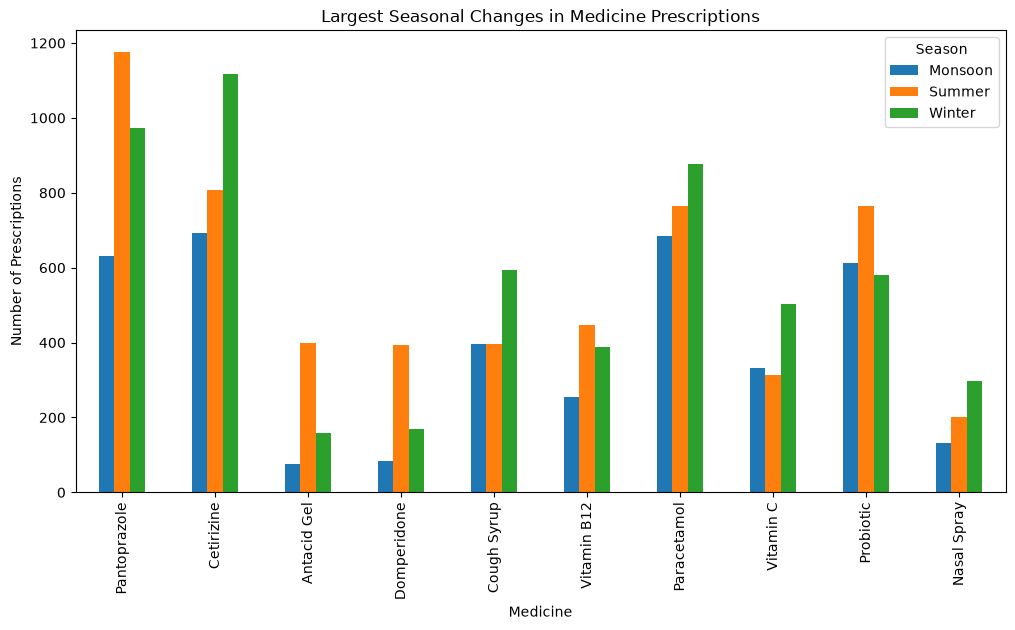

In [97]:
# 52. Which medicines experience the largest seasonal changes in prescription frequency?

season_medicine = df.groupby(["Season", "Medicine_Name"])["Prescription_ID"].nunique().reset_index()

seasonal_medicine_change = season_medicine.groupby("Medicine_Name")["Prescription_ID"].agg(lambda x: x.max() - x.min()).sort_values(ascending=False)

print("Medicines with the largest seasonal changes in prescription frequency:")
print(seasonal_medicine_change.head(10))

season_medicine.pivot(index="Medicine_Name", columns="Season", values="Prescription_ID").loc[seasonal_medicine_change.head(10).index].plot(kind="bar", figsize=(12,6))
plt.xlabel("Medicine")
plt.ylabel("Number of Prescriptions")
plt.title("Largest Seasonal Changes in Medicine Prescriptions")
plt.xticks(rotation=90)
plt.show()

In [98]:
# 53. Which doctors handle the highest number of unique prescriptions and unique patients?

doctor_analysis = df.groupby("Doctor_ID").agg(
    Prescriptions=("Prescription_ID", "nunique"),
    Patients=("Patient_ID", "nunique")
).sort_values("Prescriptions", ascending=False)

print("Doctor with the highest number of unique prescriptions:", doctor_analysis.index[0])
print("Unique prescriptions:", doctor_analysis.iloc[0]["Prescriptions"])
print("Unique patients:", doctor_analysis.iloc[0]["Patients"])

Doctor with the highest number of unique prescriptions: DOC010
Unique prescriptions: 103
Unique patients: 103


In [99]:
# 54. Which doctors are associated with the highest total medicine expenditure?

doctor_expenditure = df.groupby("Doctor_ID")["Total_Medicine_Cost"].sum().sort_values(ascending=False)

print("Doctor with the highest medicine expenditure:", doctor_expenditure.index[0])
print("Total medicine expenditure:", round(doctor_expenditure.iloc[0], 2))

Doctor with the highest medicine expenditure: DOC031
Total medicine expenditure: 594919.31


In [100]:
# 55. Which doctors have unusually high or low average prescription costs compared with others in the same department?

x = df.groupby(["Department", "Doctor_ID"]).agg(Total_Cost=("Total_Medicine_Cost", "sum"), Prescriptions=("Prescription_ID", "nunique")).assign(Average_Cost=lambda x: x["Total_Cost"] / x["Prescriptions"])
x["Difference"] = x["Average_Cost"] - x.groupby(level="Department")["Average_Cost"].transform("mean")

print("Doctor with highest cost compared with department:", x["Difference"].idxmax())
print("Difference:", round(x["Difference"].max(), 2))

print("\nDoctor with lowest cost compared with department:", x["Difference"].idxmin())
print("Difference:", round(x["Difference"].min(), 2))

Doctor with highest cost compared with department: ('Endocrinology', 'DOC042')
Difference: 7924.31

Doctor with lowest cost compared with department: ('ENT', 'DOC040')
Difference: -4041.72


In [101]:
# 56. How does the average number of medicines prescribed vary across doctors?

doctor_medicines = df.groupby(["Doctor_ID", "Prescription_ID"])["Medicine_Name"].nunique().groupby("Doctor_ID").mean().sort_values(ascending=False)

print("Doctor with the highest average number of medicines per prescription:", doctor_medicines.index[0])
print("Average number of medicines:", round(doctor_medicines.iloc[0], 2))

Doctor with the highest average number of medicines per prescription: DOC014
Average number of medicines: 3.3


Number of patients with repeated prescriptions: 3498
Patient with most prescriptions: PAT01925
Number of prescriptions: 9

Most common diagnosis: Common Cold
Most common medicine category: Vitamin/Supplement


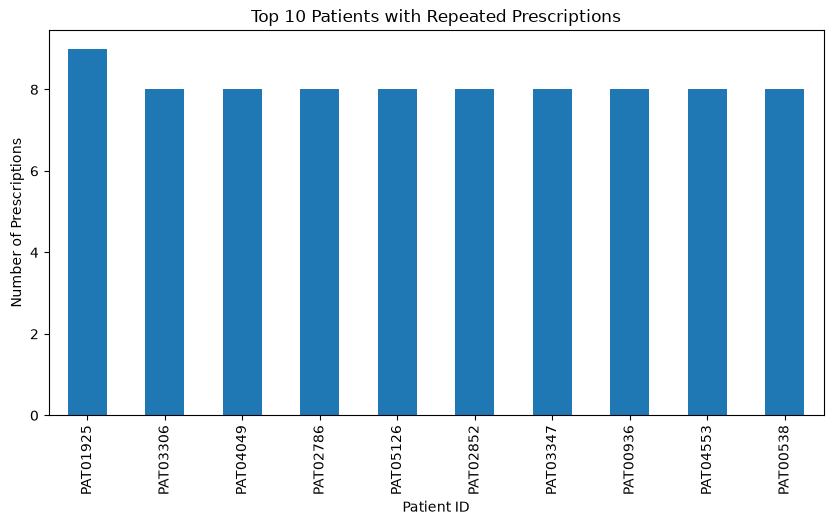

In [102]:
# 57. Which patients receive repeated prescriptions, and what diagnoses or medicine categories are most common among them?

x = df.groupby("Patient_ID")["Prescription_ID"].nunique()
repeated = x[x > 1].index

print("Number of patients with repeated prescriptions:", len(repeated))
print("Patient with most prescriptions:", x.idxmax())
print("Number of prescriptions:", x.max())

print("\nMost common diagnosis:", df[df["Patient_ID"].isin(repeated)]["Diagnosis"].value_counts().index[0])
print("Most common medicine category:", df[df["Patient_ID"].isin(repeated)]["Medicine_Category"].value_counts().index[0])

x[x > 1].sort_values(ascending=False).head(10).plot(kind="bar", figsize=(10,5))
plt.xlabel("Patient ID")
plt.ylabel("Number of Prescriptions")
plt.title("Top 10 Patients with Repeated Prescriptions")
plt.show()

Patient with highest cumulative expenditure: PAT01925
Total expenditure: 78203.85
Number of prescriptions: 9.0
Average prescription cost: 8689.32


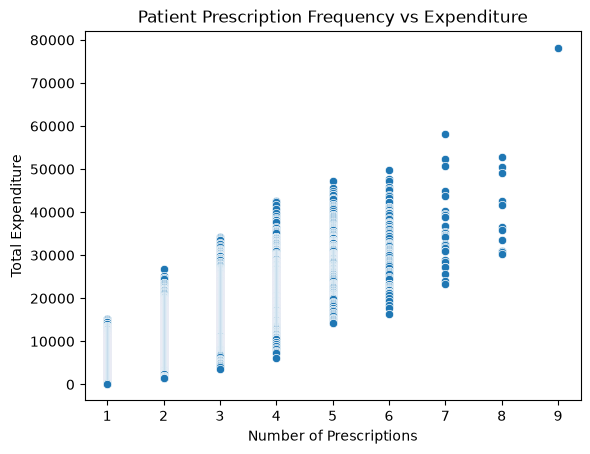

In [103]:
# 58. Which patients generate the highest cumulative medicine expenditure, and is this driven by frequent prescriptions or expensive prescriptions?

x = df.groupby("Patient_ID").agg(Prescriptions=("Prescription_ID", "nunique"), Total_Expenditure=("Total_Medicine_Cost", "sum")).assign(Average_Cost=lambda x: x["Total_Expenditure"] / x["Prescriptions"]).sort_values("Total_Expenditure", ascending=False)

print("Patient with highest cumulative expenditure:", x.index[0])
print("Total expenditure:", round(x.iloc[0]["Total_Expenditure"], 2))
print("Number of prescriptions:", x.iloc[0]["Prescriptions"])
print("Average prescription cost:", round(x.iloc[0]["Average_Cost"], 2))

sns.scatterplot(data=x, x="Prescriptions", y="Total_Expenditure")
plt.xlabel("Number of Prescriptions")
plt.ylabel("Total Expenditure")
plt.title("Patient Prescription Frequency vs Expenditure")
plt.show()

In [104]:
# 59. Which prescriptions contain unusually high numbers of medicines, quantities, or total costs?

x = df.groupby("Prescription_ID").agg(Medicines=("Medicine_Name", "nunique"), Quantity=("Quantity", "sum"), Cost=("Total_Medicine_Cost", "sum"))

print("Prescription with most medicines:", x["Medicines"].idxmax(), "-", x["Medicines"].max())
print("Prescription with highest quantity:", x["Quantity"].idxmax(), "-", x["Quantity"].max())
print("Prescription with highest cost:", x["Cost"].idxmax(), "-", round(x["Cost"].max(), 2))

Prescription with most medicines: RX000136 - 6
Prescription with highest quantity: RX000136 - 68
Prescription with highest cost: RX008580 - 22039.65


In [105]:
# 60. What common characteristics are visible among high-cost prescriptions in terms of age group, diagnosis, department, city, season, and medicine category?

cost = df.groupby("Prescription_ID")["Total_Medicine_Cost"].sum()
high = df[df["Prescription_ID"].isin(cost[cost >= cost.quantile(0.90)].index)]

print("Most common age group:", high["Age_Group"].value_counts().index[0])
print("Most common diagnosis:", high["Diagnosis"].value_counts().index[0])
print("Most common department:", high["Department"].value_counts().index[0])
print("Most common city:", high["City"].value_counts().index[0])
print("Most common season:", high["Season"].value_counts().index[0])
print("Most common medicine category:", high["Medicine_Category"].value_counts().index[0])

Most common age group: Adult
Most common diagnosis: Viral Fever
Most common department: General Medicine
Most common city: Indore
Most common season: Summer
Most common medicine category: Vitamin/Supplement


Correlation between age, quantity, unit price and total medicine cost:
                     Patient_Age  Quantity  Unit_Price  Total_Medicine_Cost
Patient_Age             1.000000  0.179561   -0.005540             0.117797
Quantity                0.179561  1.000000   -0.005137             0.666861
Unit_Price             -0.005540 -0.005137    1.000000             0.650780
Total_Medicine_Cost     0.117797  0.666861    0.650780             1.000000


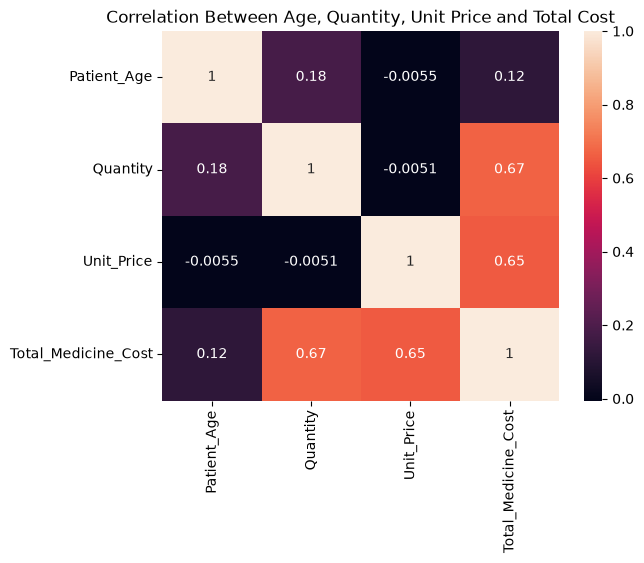

In [106]:
# 61. How strongly are patient age, quantity, unit price, and total medicine cost related?

correlation = df[["Patient_Age", "Quantity", "Unit_Price", "Total_Medicine_Cost"]].corr()

print("Correlation between age, quantity, unit price and total medicine cost:")
print(correlation)

# Correlation heatmap

sns.heatmap(correlation, annot=True)
plt.title("Correlation Between Age, Quantity, Unit Price and Total Cost")
plt.show()

In [107]:
# 62. Which variables appear to be the strongest drivers of total medicine cost?

cost_correlation = df[["Patient_Age", "Quantity", "Unit_Price", "Total_Medicine_Cost"]].corr()["Total_Medicine_Cost"].drop("Total_Medicine_Cost").abs().sort_values(ascending=False)

print("Variables most strongly related to total medicine cost:")
print(cost_correlation)

print("\nStrongest driver:", cost_correlation.index[0])
print("Correlation:", round(cost_correlation.iloc[0], 3))

Variables most strongly related to total medicine cost:
Quantity       0.666861
Unit_Price     0.650780
Patient_Age    0.117797
Name: Total_Medicine_Cost, dtype: float64

Strongest driver: Quantity
Correlation: 0.667


Average values of prescription variables:
Patient_Age              37.882226
Quantity                  7.923269
Unit_Price              233.616176
Total_Medicine_Cost    1848.247543
dtype: float64


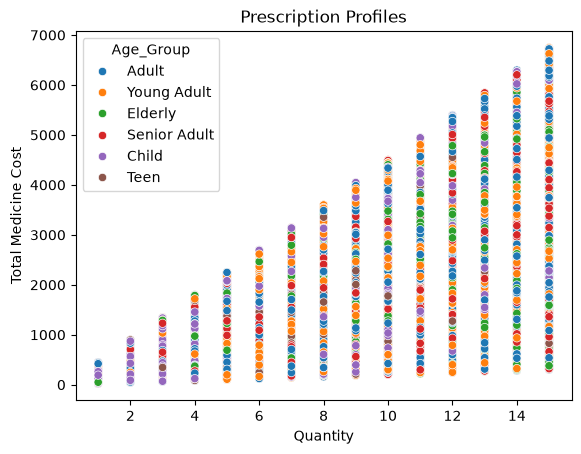

In [108]:
# 63. Are there distinct clusters or recurring profiles of prescriptions based on patient age, quantity, unit price, and total medicine cost?

x = df[["Patient_Age", "Quantity", "Unit_Price", "Total_Medicine_Cost"]]

print("Average values of prescription variables:")
print(x.mean())

sns.scatterplot(data=df, x="Quantity", y="Total_Medicine_Cost", hue="Age_Group")
plt.xlabel("Quantity")
plt.ylabel("Total Medicine Cost")
plt.title("Prescription Profiles")
plt.show()

In [109]:
# 64. Which departments or medicine categories contain the greatest number of cost outliers?

q1 = df.groupby("Department")["Total_Medicine_Cost"].transform("quantile", 0.25)
q3 = df.groupby("Department")["Total_Medicine_Cost"].transform("quantile", 0.75)
iqr = q3 - q1

outliers = df[(df["Total_Medicine_Cost"] < q1 - 1.5 * iqr) | (df["Total_Medicine_Cost"] > q3 + 1.5 * iqr)]

print("Department with most cost outliers:", outliers["Department"].value_counts().index[0])
print("Number of outliers:", outliers["Department"].value_counts().iloc[0])

print("\nMedicine category with most cost outliers:", outliers["Medicine_Category"].value_counts().index[0])
print("Number of outliers:", outliers["Medicine_Category"].value_counts().iloc[0])

Department with most cost outliers: Pediatrics
Number of outliers: 336

Medicine category with most cost outliers: Gut Health
Number of outliers: 206


In [110]:
# 65. What proportion of total expenditure is contributed by the highest-cost prescriptions, medicines, diagnoses, doctors, or patients?

total = df["Total_Medicine_Cost"].sum()

for column in ["Prescription_ID", "Medicine_Name", "Diagnosis", "Doctor_ID", "Patient_ID"]:
    x = df.groupby(column)["Total_Medicine_Cost"].sum().sort_values(ascending=False)
    print("Top 10", column, "share of total expenditure:", round(x.head(10).sum() / total * 100, 2), "%")

Top 10 Prescription_ID share of total expenditure: 0.3 %
Top 10 Medicine_Name share of total expenditure: 51.31 %
Top 10 Diagnosis share of total expenditure: 40.88 %
Top 10 Doctor_ID share of total expenditure: 8.32 %
Top 10 Patient_ID share of total expenditure: 0.81 %


Most frequently prescribed category combination: ('Vitamin/Supplement', 'Supplement')
Number of prescriptions: 1086


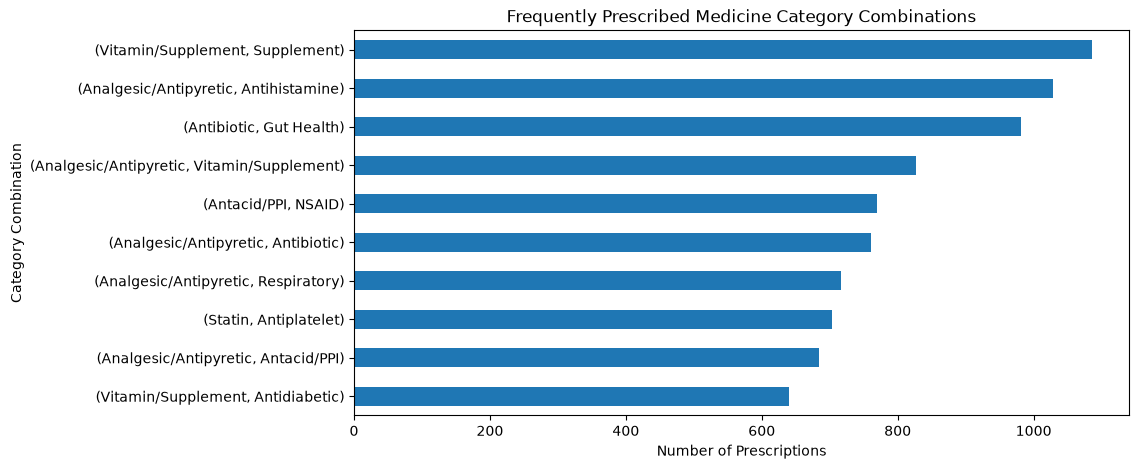

In [111]:
# 66. Which medicine-category combinations are most frequently prescribed together within the same prescription?

x = df.groupby("Prescription_ID")["Medicine_Category"].apply(lambda x: list(set(x)))
pairs = x.apply(lambda x: [(x[i], x[j]) for i in range(len(x)) for j in range(i + 1, len(x))]).explode().value_counts()

print("Most frequently prescribed category combination:", pairs.index[0])
print("Number of prescriptions:", pairs.iloc[0])

pairs.head(10).sort_values().plot(kind="barh", figsize=(10,5))
plt.xlabel("Number of Prescriptions")
plt.ylabel("Category Combination")
plt.title("Frequently Prescribed Medicine Category Combinations")
plt.show()

Number of multi-category prescriptions: 7676
Most common diagnosis: Common Cold
Number of prescriptions: 2374


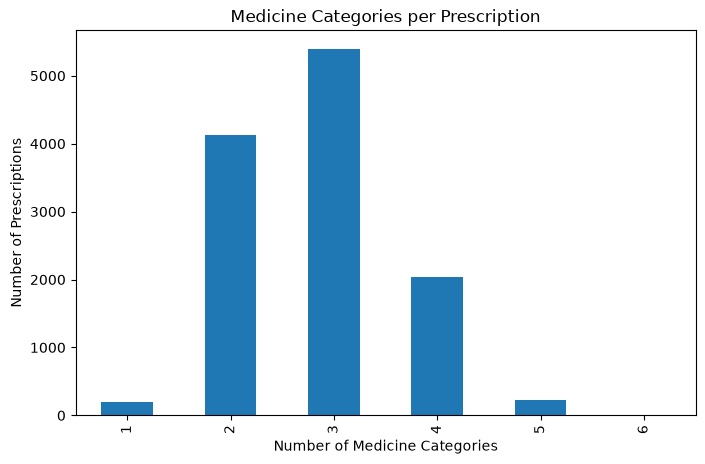

In [112]:
# 67. Which prescriptions include medicines from several different categories, and what diagnoses are most commonly associated with such prescriptions?

x = df.groupby("Prescription_ID")["Medicine_Category"].nunique()
multi = x[x > 2].index
y = df[df["Prescription_ID"].isin(multi)]["Diagnosis"].value_counts()

print("Number of multi-category prescriptions:", len(multi))
print("Most common diagnosis:", y.index[0])
print("Number of prescriptions:", y.iloc[0])

x.value_counts().sort_index().plot(kind="bar", figsize=(8,5))
plt.xlabel("Number of Medicine Categories")
plt.ylabel("Number of Prescriptions")
plt.title("Medicine Categories per Prescription")
plt.show()

In [113]:
# 68. Which diagnoses show the most consistent prescribing pattern, and which show the greatest variation in medicines, quantities, and costs?

x = df.groupby("Diagnosis").agg(Medicines=("Medicine_Name", "nunique"), Quantity_Variation=("Quantity", "std"), Cost_Variation=("Total_Medicine_Cost", "std"))

print("Diagnosis with fewest different medicines:", x["Medicines"].idxmin())
print("Diagnosis with greatest cost variation:", x["Cost_Variation"].idxmax())
print("Highest cost variation:", round(x["Cost_Variation"].max(), 2))

Diagnosis with fewest different medicines: IBS
Diagnosis with greatest cost variation: Back Pain
Highest cost variation: 1606.87


In [114]:
# 69. Where do prescription volume, average cost, and total expenditure reveal contrasting patterns that require further investigation?

x = df.groupby("Department").agg(Prescriptions=("Prescription_ID", "nunique"), Total_Expenditure=("Total_Medicine_Cost", "sum")).assign(Average_Cost=lambda x: x["Total_Expenditure"] / x["Prescriptions"])

print("Department with highest prescription volume:", x["Prescriptions"].idxmax())
print("Department with highest average cost:", x["Average_Cost"].idxmax())
print("Department with highest total expenditure:", x["Total_Expenditure"].idxmax())

Department with highest prescription volume: General Medicine
Department with highest average cost: Pulmonology
Department with highest total expenditure: General Medicine


In [115]:
# 70. Which departments, cities, diagnoses, doctors, medicines, and medicine categories should be prioritised for prescription-cost management?

for column in ["Department", "City", "Diagnosis", "Doctor_ID", "Medicine_Name", "Medicine_Category"]:
    result = df.groupby(column)["Total_Medicine_Cost"].sum().sort_values(ascending=False)
    print("\nTop", column, "for prescription-cost management:", result.index[0])
    print("Total expenditure:", round(result.iloc[0], 2))


Top Department for prescription-cost management: General Medicine
Total expenditure: 17179178.03

Top City for prescription-cost management: Nagpur
Total expenditure: 7223000.43

Top Diagnosis for prescription-cost management: Common Cold
Total expenditure: 3985987.12

Top Doctor_ID for prescription-cost management: DOC031
Total expenditure: 594919.31

Top Medicine_Name for prescription-cost management: Pantoprazole
Total expenditure: 5910083.96

Top Medicine_Category for prescription-cost management: Vitamin/Supplement
Total expenditure: 7197629.1


# Frequent Patterns Observed in the Dataset

After analysing all 70 questions, several important patterns can be observed in the prescription data.

### 1. Prescription Pattern

The dataset contains **12,000 unique prescriptions** from **4,848 unique patients**. This shows that the same patients can receive prescriptions multiple times.

### 2. Medicine Frequency Pattern

**Pantoprazole** is the most frequently prescribed medicine with **2,777 prescription records**, followed by **Cetirizine with 2,617** and **Paracetamol with 2,392**.

This shows that these medicines are commonly used in the dataset.

### 3. Medicine Category Pattern

**Vitamin/Supplement** is the most frequently recorded medicine category with **3,466 records**. **Antacid/PPI** and **Antihistamine** are also among the most common categories.

This shows that some medicine categories are used much more frequently than others.

### 4. Department Pattern

**General Medicine** has the highest prescription activity with **9,019 records**.

It also has the highest total medicine expenditure of about **17.18 million**.

This shows that General Medicine is an important department in terms of both prescription volume and expenditure.

### 5. Diagnosis Pattern

**Common Cold** is the most common diagnosis with **2,374 records**.

It also has the highest medicine expenditure among the diagnoses, at about **3.99 million**.

This shows that Common Cold is both a frequent diagnosis and an important contributor to medicine expenditure.

### 6. City Pattern

**Nagpur** has the highest prescription activity among the cities with **3,821 records**.

It also has the highest total medicine expenditure of about **7.22 million**.

This shows that Nagpur is an important city in terms of both prescription activity and expenditure.

### 7. Gender Pattern

Male patients account for **6,066 unique prescriptions**, compared with **5,810 for females** and **124 for Other**.

Male patients also have the highest total medicine quantity and expenditure.

This shows that prescription activity is slightly higher for males than females in this dataset.

### 8. Age Pattern

The dataset contains patients from **1 to 92 years old**, with an average age of about **37.88 years**.

This shows that prescriptions are distributed across children, adults and older patients.

### 9. Cost Pattern

The average medicine cost per record is about **1,848.25**, while the maximum medicine cost is about **6,746.85**.

This shows that medicine costs can vary considerably between prescription records.

### 10. Time Pattern

Prescription activity changes from month to month.

**January** has the highest prescription-record volume with **4,653 records**, while **June** has the lowest with **2,190 records**.

This shows that prescription activity is not the same throughout the year.

### 11. Medicine Combination Pattern

Several medicines are repeatedly found together in the same prescription.

For example, combinations involving **Cetirizine, Paracetamol, Vitamin C, Cough Syrup and Pantoprazole** appear repeatedly in the prescription data.

These repeated combinations are important for Association Rule Learning.

### 12. Department–Medicine Category Pattern

Different departments show different medicine-category patterns.

For example, **Antidiabetic medicines are strongly associated with Endocrinology**, while **Dermatology medicines are common in the Dermatology department**.

This shows that medicine categories are not distributed equally across departments.

### 13. High-Expenditure Pattern

Some medicines contribute a large amount to total expenditure because they are prescribed frequently.

**Pantoprazole** is the top medicine for prescription-cost management, with total expenditure of about **5.91 million**.

This shows that a medicine does not need to have the highest unit price to create high total expenditure.

### 14. Repeated Prescription Pattern

Some patients receive prescriptions more than once.

This means prescription activity is not only spread across different patients, but also repeated for the same patients over time.

### 15. Overall Pattern

The main pattern in the dataset is that a small number of medicines, diagnoses, departments and cities account for a large amount of prescription activity and expenditure.

The repeated occurrence of medicines within the same prescription also suggests that there are useful medicine combinations that can be studied using Association Rule Learning.

These patterns will now be checked using the Apriori algorithm.

# Create Prescription Transactions

In Market Basket Analysis, one customer purchase is treated as one transaction.

Here, one `Prescription_ID` will be treated as one transaction.

All medicines belonging to the same prescription will be grouped together.

In [10]:
# Group all medicines belonging to the same prescription
transactions = df.groupby("Prescription_ID")["Medicine_Name"].apply(list)

# Display the first five transactions
transactions.head()

Prescription_ID
RX000001               [Pantoprazole, Ondansetron]
RX000002                     [Calcium, Vitamin D3]
RX000003    [Paracetamol, Amoxicillin Clavulanate]
RX000004    [Nasal Spray, Cetirizine, Montelukast]
RX000005      [Cough Syrup, Salbutamol, Probiotic]
Name: Medicine_Name, dtype: object

### Observation

Each Prescription_ID now contains the medicines prescribed in that prescription.

For example, if a prescription contains two medicines, both medicines appear together in the same transaction.

### Interpretation

This converts our healthcare data into a Market Basket format.

The Prescription_ID works like a shopping basket, and the medicines work like the items inside the basket.

# Create Medicine Basket

Now we will create a basket where each row represents a prescription and each column represents a medicine.

The values will show whether a medicine is present in a prescription.

In [11]:
# Create a prescription and medicine basket
basket = df.groupby(["Prescription_ID", "Medicine_Name"])["Medicine_Name"].count().unstack(fill_value=0)

# Display the first five rows
basket.head()

Medicine_Name,ALBENDAZOLE,AMLODIPINE,AMOXICILLIN CLAVULANATE,ANTACID GEL,ANTIFUNGAL CREAM,ASPIRIN,ATORVASTATIN,AZITHROCIN,AZITHROMYCIN,Albendazole,...,Vitamin B Complex,Vitamin B12,Vitamin C,Vitamin C Syrup,Vitamin D3,Vitamin Syrup,ZINC,ZINC SYRUP,Zinc,Zinc Syrup
Prescription_ID,,,,,,,,,,,,,,,,,,,,,
RX000001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
RX000002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
RX000003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
RX000004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
RX000005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Observation
The basket matrix has Prescription_ID as rows and Medicine_Name as columns. The values show how many times a particular medicine occurs in each prescription.

### Interpretation

This basket format makes it easier to identify medicines that occur together in the same prescription.

## Convert Basket into Boolean Values

Apriori only needs to know whether a medicine is present or not.
So, we will convert the medicine counts into True and False values.

In [12]:
# Convert medicine counts into True and False
basket = basket.astype(bool)

# Display the Boolean basket
basket.head()

Medicine_Name,ALBENDAZOLE,AMLODIPINE,AMOXICILLIN CLAVULANATE,ANTACID GEL,ANTIFUNGAL CREAM,ASPIRIN,ATORVASTATIN,AZITHROCIN,AZITHROMYCIN,Albendazole,...,Vitamin B Complex,Vitamin B12,Vitamin C,Vitamin C Syrup,Vitamin D3,Vitamin Syrup,ZINC,ZINC SYRUP,Zinc,Zinc Syrup
Prescription_ID,,,,,,,,,,,,,,,,,,,,,
RX000001,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
RX000002,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
RX000003,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
RX000004,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
RX000005,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Observation

The basket now contains True and False values.
True means that the medicine is present in the prescription, while False means that the medicine is not present.

### Interpretation

The data is now in the required format for applying the Apriori algorithm.

## Check Basket Size

We will check the number of prescription transactions and medicine columns before applying Apriori.

In [13]:
# Check the number of transactions and medicines
basket.shape

(12000, 115)

### Observation

The basket contains **12,000 prescription transactions**.
The columns represent the different medicines available in the cleaned dataset.

### Interpretation

The prescription data has been successfully converted into transaction format and is ready for Apriori.

# Install and Import Apriori Tools

We will use the `mlxtend` library for Association Rule Learning.

The library contains the Apriori algorithm and the function used to generate association rules.

In [14]:
# Install the mlxtend library
%pip install -q mlxtend

/opt/anaconda3/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=13048) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


In [15]:
# Import the classic Apriori function for frequent-itemset discovery.
from mlxtend.frequent_patterns import apriori

# Import the analytical association-rules function for rule generation.
from mlxtend.frequent_patterns import association_rules


# Apply Apriori Algorithm

We will use a minimum support of 0.02.

This means that a medicine or medicine combination must appear in at least 2% of the prescription transactions to be considered frequent.

In [16]:
# Find frequent itemsets using 2% minimum support
frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)

# Display the frequent itemsets
frequent_itemsets.head()

,support,itemsets
0,0.024250,(Albendazole)
1,0.022333,(Amlodipine)
2,0.052750,(Antacid Gel)
3,0.067417,(Aspirin)
4,0.073833,(Atorvastatin)


### Observation

Apriori has identified medicines and medicine combinations that occur frequently enough to meet the minimum support of 0.02.

These are called frequent itemsets.

### Interpretation

Apriori helps us automatically find repeated combinations instead of checking every possible combination manually.

## Frequent Itemsets by Support

Now we will arrange the frequent itemsets from highest support to lowest support.
This will help us see which patterns occur most frequently.

In [17]:
# Sort frequent itemsets from highest to lowest support
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False)

# Display the top 20 frequent itemsets
frequent_itemsets.head(20)

,support,itemsets
27,0.231417,(Pantoprazole)
8,0.218083,(Cetirizine)
28,0.193833,(Paracetamol)
31,0.163167,(Probiotic)
11,0.115500,(Cough Syrup)
5,0.109917,(Azithromycin)
39,0.095833,(Vitamin C)
38,0.090750,(Vitamin B12)
41,0.084583,(Vitamin D3)
7,0.082917,(Calcium)


### Observation

The itemsets at the top have the highest support values. This means these medicines or medicine combinations occur in more prescription transactions than the itemsets below them.

### Interpretation

Higher support means that the pattern is more frequent in the dataset.

However, high support alone does not mean that two medicines have a strong association. For that, we need confidence and lift.

# Generate Association Rules

The frequent itemsets will now be converted into association rules.

A rule can be written as:

Medicine A → Medicine B

This means that Medicine B is found when Medicine A is present.

In [18]:
# Generate association rules using lift
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Display the first few rules
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Cetirizine),(Paracetamol),0.218083,0.193833,0.081417,0.373328,1.926027,1.0,0.039145,1.286426,0.614895,0.246344,0.222652,0.396681
1,(Paracetamol),(Cetirizine),0.193833,0.218083,0.081417,0.420034,1.926027,1.0,0.039145,1.348212,0.596398,0.246344,0.258277,0.396681
2,(Paracetamol),(Vitamin C),0.193833,0.095833,0.063333,0.326741,3.409473,1.0,0.044758,1.342970,0.876617,0.279823,0.255382,0.493805
3,(Vitamin C),(Paracetamol),0.095833,0.193833,0.063333,0.660870,3.409473,1.0,0.044758,2.377158,0.781603,0.279823,0.579330,0.493805
4,(Cetirizine),(Vitamin C),0.218083,0.095833,0.062167,0.285059,2.974531,1.0,0.041267,1.264674,0.848956,0.246938,0.209282,0.466877


### Observation
The Apriori frequent itemsets were converted into directional association rules.

For example:

    Albendazole → Vitamin Syrup has:
    
    Support = 0.022083
    Confidence = 0.910653
    Lift = 38.614258

This shows a strong positive association in this dataset.

### Interpretation

These three measures help us understand whether a repeated medicine pattern is actually a meaningful association.

## Association Rules Sorted by Lift

Now we will arrange the rules according to their lift value.

A higher lift means a stronger positive relationship between the medicines.

In [19]:
# Sort association rules from highest to lowest lift
rules = rules.sort_values("lift", ascending=False)

# Display the top 15 rules
rules.head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
140,(Vitamin Syrup),(Albendazole),0.023583,0.024250,0.022083,0.936396,38.614258,1.0,0.021511,15.340958,0.997630,0.857605,0.934815,0.923524
141,(Albendazole),(Vitamin Syrup),0.024250,0.023583,0.022083,0.910653,38.614258,1.0,0.021511,10.928356,0.998312,0.857605,0.908495,0.923524
159,"(Telmisartan, Vitamin B12)",(Glimepiride),0.027917,0.030167,0.021250,0.761194,25.232951,1.0,0.020408,4.061177,0.987950,0.576923,0.753766,0.732807
162,(Glimepiride),"(Telmisartan, Vitamin B12)",0.030167,0.027917,0.021250,0.704420,25.232951,1.0,0.020408,3.288731,0.990242,0.576923,0.695931,0.732807
69,"(Montelukast, Salbutamol)",(Budesonide),0.037583,0.046417,0.031583,0.840355,18.104591,1.0,0.029839,5.973140,0.981659,0.602544,0.832584,0.760393
72,(Budesonide),"(Montelukast, Salbutamol)",0.046417,0.037583,0.031583,0.680431,18.104591,1.0,0.029839,3.011607,0.990753,0.602544,0.667951,0.760393
148,(Nasal Spray),(Steam Inhalation),0.052333,0.027250,0.021667,0.414013,15.193128,1.0,0.020241,1.660019,0.985769,0.374101,0.397597,0.604560
149,(Steam Inhalation),(Nasal Spray),0.027250,0.052333,0.021667,0.795107,15.193128,1.0,0.020241,4.625179,0.960350,0.374101,0.783792,0.604560
197,(Glimepiride),"(Vitamin B12, Metformin)",0.030167,0.045750,0.020000,0.662983,14.491441,1.0,0.018620,2.831463,0.959952,0.357675,0.646826,0.550071
196,"(Vitamin B12, Metformin)",(Glimepiride),0.045750,0.030167,0.020000,0.437158,14.491441,1.0,0.018620,1.723102,0.975629,0.357675,0.419651,0.550071


### Observation

The rules at the top have the highest lift values. These rules show stronger relationships between the medicines compared with the rules having lower lift.

### Interpretation

A lift greater than 1 indicates a positive association. A lift equal to 1 means there is no meaningful association, while a lift below 1 indicates a negative relationship.

# Understanding Support, Confidence and Lift

### Support

Support tells us how frequently an item or combination appears in all transactions.

### Confidence

Confidence tells us how often the consequent is present when the antecedent is present.

### Lift

Lift tells us how strong the relationship is between the antecedent and consequent.

- Lift > 1 → Positive relationship
- Lift = 1 → No meaningful relationship
- Lift < 1 → Negative relationship

## Filter Strong Association Rules

To focus on stronger relationships, we will keep rules with confidence of at least 50% and lift greater than 1.20.

In [20]:
# filter rules that show both meaningful confidence and strong positive lift.
strong_rules = rules[(rules['confidence'] >= 0.50) & (rules['lift'] > 1.20)].copy()

# sort the filtered rules from highest to lowest lift.
strong_rules = strong_rules.sort_values(by=['lift', 'confidence'], ascending=False)

# display the key metrics for the strongest filtered rules.
strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(30)


,antecedents,consequents,support,confidence,lift
140,(Vitamin Syrup),(Albendazole),0.022083,0.936396,38.614258
141,(Albendazole),(Vitamin Syrup),0.022083,0.910653,38.614258
159,"(Telmisartan, Vitamin B12)",(Glimepiride),0.021250,0.761194,25.232951
162,(Glimepiride),"(Telmisartan, Vitamin B12)",0.021250,0.704420,25.232951
69,"(Montelukast, Salbutamol)",(Budesonide),0.031583,0.840355,18.104591
72,(Budesonide),"(Montelukast, Salbutamol)",0.031583,0.680431,18.104591
149,(Steam Inhalation),(Nasal Spray),0.021667,0.795107,15.193128
197,(Glimepiride),"(Vitamin B12, Metformin)",0.020000,0.662983,14.491441
47,(Antacid Gel),(Domperidone),0.040500,0.767773,14.262028
46,(Domperidone),(Antacid Gel),0.040500,0.752322,14.262028


### Observation
After filtering for confidence ≥ 0.50 and lift > 1.20, the remaining rules represent stronger positive associations.

    The strongest rule is:  
    Vitamin Syrup → Albendazole
    with approximately 93.64% confidence and 38.61 lift.

# Make Association Rules Easy to Read
### Convert Association Rules into Readable Format

The antecedents and consequents are currently stored as sets. We will convert them into normal text so the rules are easier to understand.

In [21]:
# Convert antecedents into readable text
strong_rules["antecedents"] = strong_rules["antecedents"].apply(lambda x: ", ".join(sorted(x)))

# Convert consequents into readable text
strong_rules["consequents"] = strong_rules["consequents"].apply(lambda x: ", ".join(sorted(x)))

# Create an easy-to-read rule
strong_rules["Rule"] = strong_rules["antecedents"] + " → " + strong_rules["consequents"]

# Display the readable rules
strong_rules[["Rule", "support", "confidence", "lift"]].head(15)

,Rule,support,confidence,lift
140,Vitamin Syrup → Albendazole,0.022083,0.936396,38.614258
141,Albendazole → Vitamin Syrup,0.022083,0.910653,38.614258
159,"Telmisartan, Vitamin B12 → Glimepiride",0.021250,0.761194,25.232951
162,"Glimepiride → Telmisartan, Vitamin B12",0.021250,0.704420,25.232951
69,"Montelukast, Salbutamol → Budesonide",0.031583,0.840355,18.104591
72,"Budesonide → Montelukast, Salbutamol",0.031583,0.680431,18.104591
149,Steam Inhalation → Nasal Spray,0.021667,0.795107,15.193128
197,"Glimepiride → Metformin, Vitamin B12",0.020000,0.662983,14.491441
47,Antacid Gel → Domperidone,0.040500,0.767773,14.262028
46,Domperidone → Antacid Gel,0.040500,0.752322,14.262028


### Observation
The antecedents and consequents were converted from set-like values into normal text. This makes the association rules easier to read and interpret.

    For example:
    
    (Vitamin Syrup) → (Albendazole)
    
    becomes:
    
    Vitamin Syrup → Albendazole

# Visualisation of Association Rules

We will use a bar graph to compare the strongest association rules based on lift.

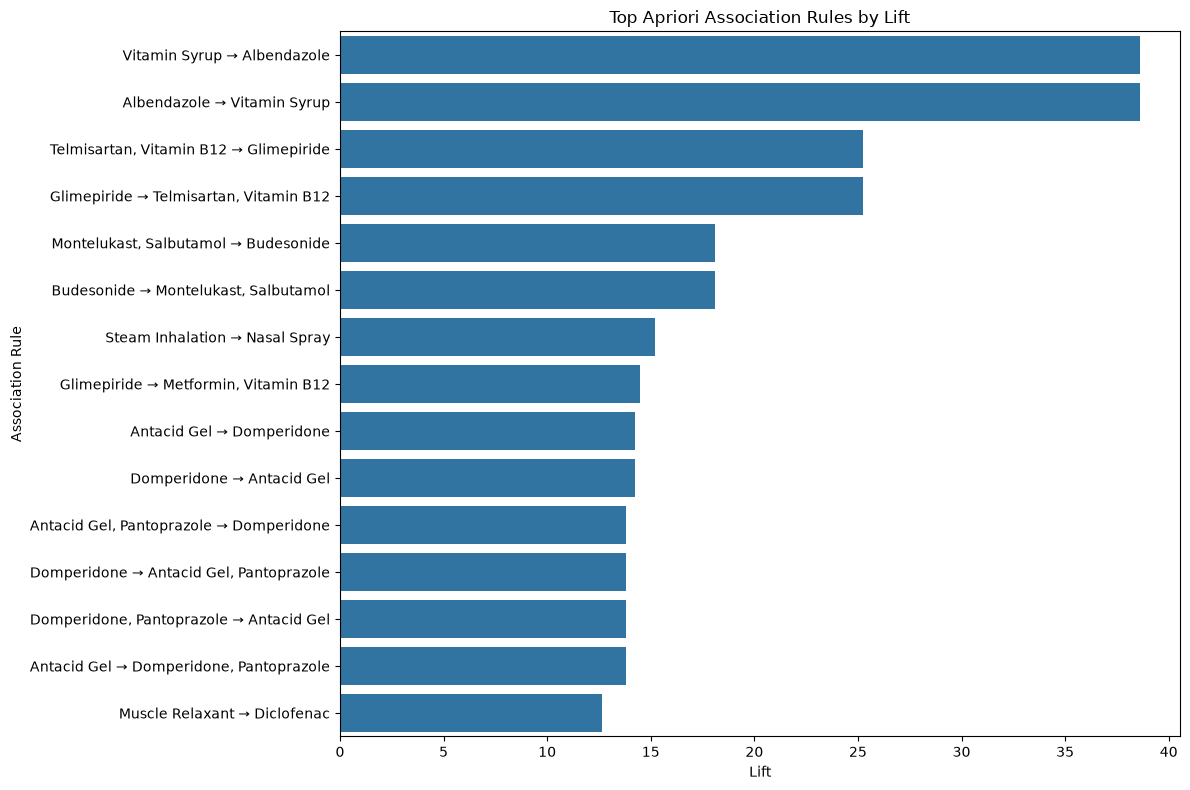

In [22]:
# Select the top 15 rules
top_rules = strong_rules.head(15)

# Plot the rules by lift
plt.figure(figsize=(12, 8))
sns.barplot(data=top_rules, x="lift", y="Rule")
plt.title("Top Apriori Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.tight_layout()
plt.show()

### Observation

The bar graph shows the association rules with the highest lift. The longer bars represent rules with stronger positive relationships between the medicines.

### Interpretation

The rules with the highest lift are the strongest associations found by the Apriori analysis. These rules are more interesting than simply looking at which medicines are prescribed most often.

## Support vs Confidence

This graph helps us compare the support and confidence of the association rules. The bubble size represents lift.

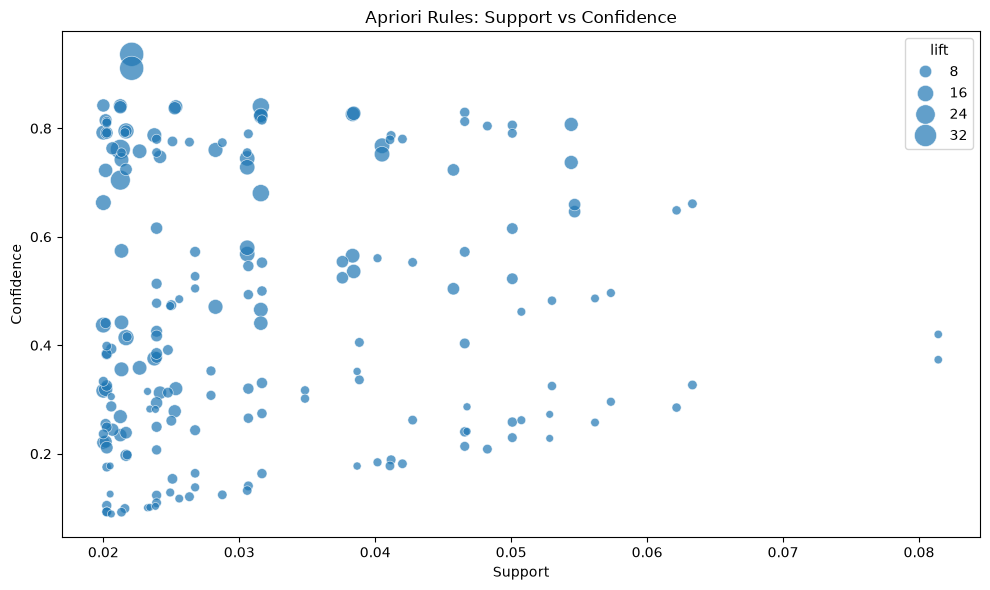

In [23]:
# Plot support against confidence
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules, x="support", y="confidence", size="lift", sizes=(30, 300), alpha=0.7)
plt.title("Apriori Rules: Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.tight_layout()
plt.show()

### Observation

The scatter plot shows that the association rules have different support and confidence values. The larger bubbles represent rules with higher lift.

### Interpretation

The graph shows why support, confidence and lift should be considered together. A rule may have high confidence but occur in only a small number of prescriptions, so support is also important.

# Overall Interpretation

Overall, the analysis shows clear patterns in prescription behaviour across medicines, diagnoses, departments, cities, time periods, and patients. Common medicines such as Pantoprazole, Cetirizine, and Paracetamol are highly frequent, while the Apriori analysis reveals that some medicines also have strong associations when prescribed together. For example, Vitamin Syrup → Albendazole has a very high confidence of 93.64% and lift of 38.61. This shows that combining the 70-question analysis with Apriori gives a deeper understanding of both common prescription trends and hidden medicine combinations.dicines, but the strongest association by lift is not necessarily formed by the most frequently prescribed medicines. For example, Vitamin Syrup and Albendazole have relatively low individual support, but their combination has a very high lift. This means that a medicine combination can be highly informative even when the individual medicines are not among the most common medicines in the dataset.

# Overall Project Insight

1. Pantoprazole, Cetirizine, and Paracetamol are among the most frequently prescribed medicines.

2. Pantoprazole contributes a large amount to total medicine expenditure because of its high prescription frequency and quantity.

3. Common Cold is one of the leading diagnoses in the dataset.

4. Some diagnoses show clear medicine patterns, such as Common Cold with Paracetamol and Gastritis with Pantoprazole.

5. Prescription volume and expenditure vary across departments, cities, months, and seasons.

6. Summer has the highest seasonal prescription volume and expenditure.

7. Some medicines are repeatedly prescribed together, such as Cetirizine + Paracetamol and Paracetamol + Vitamin C.

8. Apriori identified some strong medicine associations that were not obvious from simple frequency analysis.

9. The strongest association found was Vitamin Syrup → Albendazole, with 93.64% confidence and 38.61 lift.

10. Overall, the project shows that EDA helps us understand the main prescription patterns, while Apriori helps us find medicines that are frequently associated with each other.